# Steam Data Processing Pipeline (2021-2025)

This notebook performs comprehensive data processing on the Steam games dataset following standard data science practices:
1. **Data Loading** - Import and initial inspection
2. **Data Exploration** - Understanding the structure and content
3. **Data Cleaning** - Handle missing values, duplicates, and data types
4. **Data Transformation** - Organize and process for analysis
5. **Data Validation** - Quality checks and final preparation

## 🎯 Research Focus
This project explores the evolution of indie games on Steam between 2021 and 2025, comparing their market presence and recognition with AAA titles. The core questions driving the analysis are:

1. **📈 Market Evolution** – How has the indie games market evolved between 2021 and 2025 compared to other games? Are indie studios gaining or losing ground in terms of releases, pricing strategies, and player engagement?

2. **🎮 Genre Popularity** – What types of genres are the most popular among indie games versus AAA titles? Which genres dominate the indie space, and how do player preferences differ across segments?

3. **💰 Price-to-Engagement Impact** – How does price impact recommendations and player engagement? Do indie games at certain price points perform better than AAA counterparts?

4. **🏆 Awards Recognition** – Are indie games starting to be more noticed in Steam Awards? Is there a shift in recognition toward indie developers, and which categories do they dominate?

These questions guide the data processing, analysis, and visualizations built throughout the notebook and reflected in the interactive Streamlit dashboard.

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and time handling
from datetime import datetime

# File system & databases
from pathlib import Path
import sqlite3

# Data quality and warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

ModuleNotFoundError: No module named 'matplotlib'

## 2. Load Data

In [ ]:
# Load the CSV file with semicolon delimiter
df = pd.read_csv('data/a_steam_data_2021_2025.csv', sep=';')

print(f"Data loaded successfully!")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Data loaded successfully!
Dataset shape: 65521 rows × 10 columns


## 3. Initial Data Exploration

In [ ]:
# Display first few rows
print("="*80)
print("FIRST 5 ROWS")
print("="*80)
display(df.head())

print("\n" + "="*80)
print("LAST 5 ROWS")
print("="*80)
display(df.tail())

FIRST 5 ROWS


,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,3057270,Seafarer's Gambit,2024,"Jul 5, 2024",Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,3822840,Capitalist Misadventures,2025,"Jul 25, 2025",Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios
2,3216640,The Beast and the Princess,2025,"Jun 17, 2025",Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames
3,2403620,Air Twister,2023,"Nov 10, 2023",Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ
4,1538040,Horde Slayer,2021,"Mar 19, 2021",Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues



LAST 5 ROWS


,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
65516,3097010,X Simulator Drone,2024,"Jul 31, 2024",Casual;Indie;Simulation,Single-player;Family Sharing,14.99,0,Inonia Games,Inonia Games
65517,3304930,Retro Dungeon Slayer,2025,"Mar 3, 2025",Action;Indie;Early Access,Single-player;Family Sharing,4.99,0,Hard Shark Games,Hard Shark Games
65518,1461580,Molecule Builder,2021,"Feb 4, 2021",Simulation;Education,Single-player;Tracked Controller Support;VR On...,14.99,0,Xennial Digital,Xennial Digital
65519,1379120,MechNest,2024,"Apr 13, 2024",Action;Indie,Single-player;Partial Controller Support;Famil...,15.99,0,PoisonGames,PoisonGames
65520,1580420,Ambidextrous Psychopath,2021,"Jun 28, 2021",Casual;Indie,Single-player;Family Sharing,0.99,0,Rylan Yancey,Rylan Yancey


In [ ]:
# Basic information about the dataset
print("="*80)
print("DATASET INFORMATION")
print("="*80)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65521 entries, 0 to 65520
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            65521 non-null  int64  
 1   name             65521 non-null  object 
 2   release_year     65521 non-null  int64  
 3   release_date     65521 non-null  object 
 4   genres           65455 non-null  object 
 5   categories       65514 non-null  object 
 6   price            65521 non-null  float64
 7   recommendations  65521 non-null  int64  
 8   developer        65468 non-null  object 
 9   publisher        65338 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 5.0+ MB


In [ ]:
# Statistical summary
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
display(df.describe())

print("\n" + "="*80)
print("COLUMN DATA TYPES")
print("="*80)
print(df.dtypes)

STATISTICAL SUMMARY


,appid,release_year,price,recommendations
count,6.552100e+04,65521.000000,65521.000000,65521.000000
mean,2.580607e+06,2023.453091,7.204043,362.165336
std,7.692480e+05,1.386641,16.914429,6936.837198
min,1.200220e+06,2021.000000,0.000000,0.000000
25%,1.916970e+06,2022.000000,0.990000,0.000000
50%,2.516050e+06,2024.000000,3.990000,0.000000
75%,3.193800e+06,2025.000000,9.740000,0.000000
max,4.243930e+06,2025.000000,1900.000000,862487.000000



COLUMN DATA TYPES
appid                int64
name                object
release_year         int64
release_date        object
genres              object
categories          object
price              float64
recommendations      int64
developer           object
publisher           object
dtype: object


## 4. Data Quality Assessment

In [ ]:
# Check for missing values
print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    display(missing_data)
else:
    print("No missing values found!")
    
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUES ANALYSIS


,Column,Missing_Count,Missing_Percentage
publisher,publisher,183,0.28
genres,genres,66,0.10
developer,developer,53,0.08
categories,categories,7,0.01



Total missing values: 309


In [ ]:
# Check for duplicate rows
print("="*80)
print("DUPLICATE ROWS ANALYSIS")
print("="*80)

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print(f"Percentage of duplicates: {(duplicate_count/len(df)*100):.2f}%")
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("No duplicate rows found!")

DUPLICATE ROWS ANALYSIS


Number of duplicate rows: 0
No duplicate rows found!


In [ ]:
# Check unique values in categorical columns
print("="*80)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*80)

categorical_cols = ['name', 'genres', 'categories', 'developer', 'publisher']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(f"  - Unique values: {df[col].nunique()}")
        print(f"  - Sample values: {df[col].value_counts().head(3).to_dict()}")

UNIQUE VALUES IN CATEGORICAL COLUMNS

NAME:
  - Unique values: 65128
  - Sample values: {'Echoes': 5, 'Zombie Hunter': 5, 'Loop': 4}

GENRES:
  - Unique values: 1723
  - Sample values: {'Casual;Indie': 4136, 'Action;Adventure;Indie': 2883, 'Action;Indie': 2632}

CATEGORIES:
  - Unique values: 7993
  - Sample values: {'Single-player;Family Sharing': 15071, 'Single-player;Steam Achievements;Family Sharing': 6242, 'Single-player': 3164}

DEVELOPER:
  - Unique values: 45673
  - Sample values: {'EroticGamesClub': 215, 'Bully Revenge Studios': 119, 'Gamesforgames': 96}

PUBLISHER:
  - Unique values: 41584
  - Sample values: {'EroticGamesClub': 215, 'BFG Entertainment': 172, '8floor': 150}


## 5. Data Cleaning

In [ ]:
# Create a copy for cleaning
df_clean = df.copy()

print("="*80)
print("STEP 1: REMOVING DUPLICATES")
print("="*80)

# Remove duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
removed_duplicates = initial_rows - len(df_clean)
print(f"Removed {removed_duplicates} duplicate rows")
print(f"Remaining rows: {len(df_clean)}")

STEP 1: REMOVING DUPLICATES
Removed 0 duplicate rows
Remaining rows: 65521


In [ ]:
print("\n" + "="*80)
print("STEP 2: HANDLING MISSING VALUES")
print("="*80)

# Fill missing values strategically
# For developer/publisher, use 'Unknown'
if 'developer' in df_clean.columns:
    missing_dev = df_clean['developer'].isnull().sum()
    df_clean['developer'] = df_clean['developer'].fillna('Unknown')
    print(f"Filled {missing_dev} missing developer values with 'Unknown'")

if 'publisher' in df_clean.columns:
    missing_pub = df_clean['publisher'].isnull().sum()
    df_clean['publisher'] = df_clean['publisher'].fillna('Unknown')
    print(f"Filled {missing_pub} missing publisher values with 'Unknown'")

# For genres/categories, use 'Unspecified'
if 'genres' in df_clean.columns:
    missing_genres = df_clean['genres'].isnull().sum()
    df_clean['genres'] = df_clean['genres'].fillna('Unspecified')
    print(f"Filled {missing_genres} missing genres values with 'Unspecified'")

if 'categories' in df_clean.columns:
    missing_cats = df_clean['categories'].isnull().sum()
    df_clean['categories'] = df_clean['categories'].fillna('Unspecified')
    print(f"Filled {missing_cats} missing categories values with 'Unspecified'")

# For numeric columns (price, recommendations), use 0
if 'price' in df_clean.columns:
    missing_price = df_clean['price'].isnull().sum()
    df_clean['price'] = df_clean['price'].fillna(0)
    print(f"Filled {missing_price} missing price values with 0")

if 'recommendations' in df_clean.columns:
    missing_rec = df_clean['recommendations'].isnull().sum()
    df_clean['recommendations'] = df_clean['recommendations'].fillna(0)
    print(f"Filled {missing_rec} missing recommendations values with 0")

print(f"\nTotal missing values remaining: {df_clean.isnull().sum().sum()}")


STEP 2: HANDLING MISSING VALUES
Filled 53 missing developer values with 'Unknown'
Filled 183 missing publisher values with 'Unknown'
Filled 66 missing genres values with 'Unspecified'
Filled 7 missing categories values with 'Unspecified'
Filled 0 missing price values with 0
Filled 0 missing recommendations values with 0

Total missing values remaining: 0


In [ ]:
print("\n" + "="*80)
print("STEP 3: DATA TYPE CONVERSION")
print("="*80)

# Ensure correct data types
if 'appid' in df_clean.columns:
    df_clean['appid'] = df_clean['appid'].astype('int64')
    print("✓ appid converted to int64")

if 'release_year' in df_clean.columns:
    df_clean['release_year'] = pd.to_numeric(df_clean['release_year'], errors='coerce')
    print("✓ release_year converted to numeric")

if 'price' in df_clean.columns:
    df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce').fillna(0)
    print("✓ price converted to numeric")

if 'recommendations' in df_clean.columns:
    df_clean['recommendations'] = pd.to_numeric(df_clean['recommendations'], errors='coerce').fillna(0).astype('int64')
    print("✓ recommendations converted to int64")

# Convert text columns to string type
text_columns = ['name', 'release_date', 'genres', 'categories', 'developer', 'publisher']
for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('str')
        
print("✓ All text columns converted to string type")


STEP 3: DATA TYPE CONVERSION
✓ appid converted to int64
✓ release_year converted to numeric
✓ price converted to numeric
✓ recommendations converted to int64
✓ All text columns converted to string type


In [ ]:
print("\n" + "="*80)
print("STEP 4: TEXT CLEANING")
print("="*80)

# Strip whitespace from string columns
text_columns = ['name', 'genres', 'categories', 'developer', 'publisher']
for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].str.strip()
        
print("✓ Removed leading/trailing whitespace from text columns")

# Remove rows with invalid app names (if any)
if 'name' in df_clean.columns:
    invalid_names = df_clean['name'].isin(['nan', 'None', '', 'Unknown'])
    removed_invalid = invalid_names.sum()
    df_clean = df_clean[~invalid_names]
    print(f"✓ Removed {removed_invalid} rows with invalid game names")

print(f"\nCleaned dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")


STEP 4: TEXT CLEANING
✓ Removed leading/trailing whitespace from text columns
✓ Removed 1 rows with invalid game names

Cleaned dataset shape: 65520 rows × 10 columns


In [ ]:
print("\n" + "="*80)
print("STEP 5: VALIDATING CRITICAL FIELDS & FILTERING INVALID ENTRIES")
print("="*80)

# Define what constitutes invalid values
invalid_values = ['nan', 'None', '', 'Unknown', 'Unspecified', 'N/A', 'NA']

# Split genres by semicolon for better analysis
if 'genres' in df_clean.columns:
    # First, split the genres
    df_clean['genres_split'] = df_clean['genres'].str.split(';').apply(
        lambda x: [g.strip() for g in x] if isinstance(x, list) else []
    )
    print("✓ Split genres by semicolon for better analysis")

# Check for valid genre (REQUIRED - games without valid genre will be separated)
if 'genres' in df_clean.columns:
    # A valid genre means: not empty, not in invalid_values list, and has actual content
    valid_genre_mask = (
        (~df_clean['genres'].isin(invalid_values)) & 
        (df_clean['genres'].str.len() > 0) &
        (df_clean['genres'].notna())
    )
    
    # Separate invalid entries (no valid genre)
    df_invalid = df_clean[~valid_genre_mask].copy()
    df_clean = df_clean[valid_genre_mask].copy()
    
    print(f"✓ Separated {len(df_invalid)} games WITHOUT valid genre (saved separately)")
    print(f"✓ Retained {len(df_clean)} games WITH valid genre")

# For developer and publisher, just flag them but don't remove
if 'developer' in df_clean.columns:
    invalid_dev = df_clean['developer'].isin(invalid_values)
    df_clean['has_valid_developer'] = (~invalid_dev).astype(int)
    print(f"✓ Flagged games with valid developer: {df_clean['has_valid_developer'].sum():,}")

if 'publisher' in df_clean.columns:
    invalid_pub = df_clean['publisher'].isin(invalid_values)
    df_clean['has_valid_publisher'] = (~invalid_pub).astype(int)
    print(f"✓ Flagged games with valid publisher: {df_clean['has_valid_publisher'].sum():,}")

# Save the invalid entries dataset for reference
if len(df_invalid) > 0:
    invalid_output = 'data/steam_data_invalid_genre.csv'
    df_invalid.to_csv(invalid_output, sep=';', index=False, encoding='utf-8')
    print(f"\n✓ Invalid entries saved to: {invalid_output}")

print(f"\nFinal cleaned dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")


STEP 5: VALIDATING CRITICAL FIELDS & FILTERING INVALID ENTRIES
✓ Split genres by semicolon for better analysis
✓ Separated 66 games WITHOUT valid genre (saved separately)
✓ Retained 65454 games WITH valid genre
✓ Flagged games with valid developer: 65,408
✓ Flagged games with valid publisher: 65,278

✓ Invalid entries saved to: data/steam_data_invalid_genre.csv

Final cleaned dataset shape: 65454 rows × 13 columns


## 6. Data Transformation & Feature Engineering

In [ ]:
print("="*80)
print("CREATING NEW FEATURES")
print("="*80)

# 1. Use the already-split genres and add genre count
if 'genres_split' in df_clean.columns:
    df_clean['genres_list'] = df_clean['genres_split']  # Use the pre-split genres
    df_clean['genre_count'] = df_clean['genres_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print("✓ Using pre-split genres and created 'genre_count' feature")
elif 'genres' in df_clean.columns:
    # Fallback if genres_split doesn't exist
    df_clean['genres_list'] = df_clean['genres'].str.split(';')
    df_clean['genre_count'] = df_clean['genres_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print("✓ Created 'genres_list' and 'genre_count' features")

# 2. Parse categories into list
if 'categories' in df_clean.columns:
    df_clean['categories_list'] = df_clean['categories'].str.split(';')
    df_clean['category_count'] = df_clean['categories_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print("✓ Created 'categories_list' and 'category_count' features")

# 3. Price categories
if 'price' in df_clean.columns:
    df_clean['price_category'] = pd.cut(
        df_clean['price'],
        bins=[-0.01, 0, 5, 15, 30, float('inf')],
        labels=['Free', 'Budget', 'Standard', 'Premium', 'Expensive']
    )
    print("✓ Created 'price_category' feature")

# 4. Popularity based on recommendations
if 'recommendations' in df_clean.columns:
    df_clean['popularity'] = pd.cut(
        df_clean['recommendations'],
        bins=[-1, 0, 100, 1000, 5000, float('inf')],
        labels=['None', 'Low', 'Medium', 'High', 'Very High']
    )
    print("✓ Created 'popularity' feature")

# 5. Check if game is free
if 'price' in df_clean.columns:
    df_clean['is_free'] = (df_clean['price'] == 0).astype(int)
    print("✓ Created 'is_free' feature")

# 6. Check for Early Access
if 'categories' in df_clean.columns:
    df_clean['is_early_access'] = df_clean['categories'].str.contains('Early Access', case=False, na=False).astype(int)
    print("✓ Created 'is_early_access' feature")

# 7. Check for multiplayer
if 'categories' in df_clean.columns:
    df_clean['is_multiplayer'] = df_clean['categories'].str.contains('Multi-player', case=False, na=False).astype(int)
    print("✓ Created 'is_multiplayer' feature")

# 8. Flag indie games once for reuse
if 'genres_list' in df_clean.columns:
    df_clean['is_indie'] = df_clean['genres_list'].apply(
        lambda x: int(isinstance(x, list) and 'Indie' in x)
    )
    print("✓ Created 'is_indie' indicator for downstream analysis")

print(f"\nNew dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

CREATING NEW FEATURES
✓ Using pre-split genres and created 'genre_count' feature
✓ Created 'categories_list' and 'category_count' features
✓ Created 'price_category' feature
✓ Created 'popularity' feature
✓ Created 'is_free' feature
✓ Created 'is_early_access' feature
✓ Created 'is_multiplayer' feature
✓ Created 'is_indie' indicator for downstream analysis

New dataset shape: 65454 rows × 23 columns


In [ ]:
# Helper functions reused across indie vs non-indie analyses
def split_indie_segments(df):
    """Return separate DataFrames for indie and non-indie games using the `is_indie` flag."""
    if 'is_indie' not in df.columns:
        raise KeyError("Column 'is_indie' is required. Run the feature engineering cell first.")
    indie_df = df[df['is_indie'] == 1].copy()
    non_indie_df = df[df['is_indie'] == 0].copy()
    return indie_df, non_indie_df

def compute_threshold_share(df, column, thresholds):
    """Compute percentage of rows meeting or exceeding each threshold for a numeric column."""
    results = []
    total_rows = len(df)
    for threshold in thresholds:
        if total_rows == 0:
            pct = 0.0
        else:
            pct = (df[column] >= threshold).mean() * 100
        results.append({'threshold': threshold, 'share_pct': round(pct, 2)})
    return results

def yearly_segment_aggregation(df, value_col, agg='mean'):
    """Aggregate a value by release year and indie segment using the requested aggregation."""
    required_cols = {'release_year', 'is_indie', value_col}
    missing = required_cols.difference(df.columns)
    if missing:
        raise KeyError(f"Missing columns for aggregation: {missing}")
    group_obj = df.groupby(['release_year', 'is_indie'])[value_col]
    aggregated = getattr(group_obj, agg)().reset_index()
    aggregated['segment'] = aggregated['is_indie'].map({1: 'Indie', 0: 'Non-Indie'})
    return aggregated

In [ ]:
print("\n" + "="*80)
print("EXTRACTING PRIMARY GENRE")
print("="*80)

# Extract the primary (first) genre
if 'genres_list' in df_clean.columns:
    df_clean['primary_genre'] = df_clean['genres_list'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'Unspecified'
    )
    print("✓ Created 'primary_genre' feature")
    print(f"\nTop 10 primary genres:")
    print(df_clean['primary_genre'].value_counts().head(10))


EXTRACTING PRIMARY GENRE
✓ Created 'primary_genre' feature

Top 10 primary genres:
primary_genre
Action                   25719
Casual                   15355
Adventure                14124
Indie                     6064
Simulation                1388
RPG                       1172
Strategy                   831
Free To Play               278
Racing                     277
Massively Multiplayer      123
Name: count, dtype: int64


## 7. Data Validation & Quality Checks

In [ ]:
print("="*80)
print("VALIDATION CHECKS")
print("="*80)

# Check 1: No missing values in critical columns
critical_columns = ['appid', 'name', 'release_year']
missing_critical = df_clean[critical_columns].isnull().sum()
print("\n1. Missing values in critical columns:")
print(missing_critical)

# Check 2: Data type validation
print("\n2. Data type validation:")
print(df_clean.dtypes)

# Check 3: Value ranges
print("\n3. Value range validation:")
if 'price' in df_clean.columns:
    print(f"   Price: Min={df_clean['price'].min():.2f}, Max={df_clean['price'].max():.2f}")
if 'recommendations' in df_clean.columns:
    print(f"   Recommendations: Min={df_clean['recommendations'].min()}, Max={df_clean['recommendations'].max()}")
if 'release_year' in df_clean.columns:
    print(f"   Release Year: Min={df_clean['release_year'].min()}, Max={df_clean['release_year'].max()}")

# Check 4: Outliers in price
print("\n4. Price distribution:")
if 'price' in df_clean.columns:
    price_stats = df_clean['price'].describe()
    print(price_stats)
    
print("\n✓ All validation checks completed!")

VALIDATION CHECKS

1. Missing values in critical columns:
appid           0
name            0
release_year    0
dtype: int64

2. Data type validation:
appid                     int64
name                     object
release_year              int64
release_date             object
genres                   object
categories               object
price                   float64
recommendations           int64
developer                object
publisher                object
genres_split             object
has_valid_developer       int64
has_valid_publisher       int64
genres_list              object
genre_count               int64
categories_list          object
category_count            int64
price_category         category
popularity             category
is_free                   int64
is_early_access           int64
is_multiplayer            int64
is_indie                  int64
primary_genre            object
dtype: object

3. Value range validation:
   Price: Min=0.00, Max=1900.00
   Reco

## 8. Summary Statistics & Insights

In [ ]:
print("="*80)
print("PROCESSED DATASET SUMMARY")
print("="*80)

print(f"\n📊 Dataset Overview:")
print(f"   Total games: {len(df_clean):,}")
print(f"   Total features: {df_clean.shape[1]}")
print(f"   Memory usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n💰 Price Statistics:")
if 'price' in df_clean.columns:
    print(f"   Average price: ${df_clean['price'].mean():.2f}")
    print(f"   Median price: ${df_clean['price'].median():.2f}")
    print(f"   Free games: {(df_clean['price'] == 0).sum():,} ({(df_clean['price'] == 0).sum()/len(df_clean)*100:.1f}%)")

print(f"\n⭐ Recommendations Statistics:")
if 'recommendations' in df_clean.columns:
    print(f"   Average recommendations: {df_clean['recommendations'].mean():.0f}")
    print(f"   Median recommendations: {df_clean['recommendations'].median():.0f}")
    print(f"   Games with recommendations: {(df_clean['recommendations'] > 0).sum():,}")

print(f"\n📅 Release Year Distribution:")
if 'release_year' in df_clean.columns:
    year_dist = df_clean['release_year'].value_counts().sort_index()
    for year in sorted(df_clean['release_year'].unique()):
        if not pd.isna(year):
            count = (df_clean['release_year'] == year).sum()
            print(f"   {int(year)}: {count:,} games")

print(f"\n🎮 Top 10 Genres (counting all genres per game):")
if 'genres_list' in df_clean.columns:
    # Use exploded method to count ALL genres
    genre_expanded = df_clean.explode('genres_list')
    top_genres = genre_expanded['genres_list'].value_counts().head(10)
    for genre, count in top_genres.items():
        print(f"   {genre}: {count:,} ({count/len(df_clean)*100:.1f}%)")


PROCESSED DATASET SUMMARY

📊 Dataset Overview:
   Total games: 65,454
   Total features: 24
   Memory usage: 60.57 MB

💰 Price Statistics:
   Average price: $7.21
   Median price: $3.99
   Free games: 11,948 (18.3%)

⭐ Recommendations Statistics:
   Average recommendations: 362
   Median recommendations: 0
   Games with recommendations: 7,968

📅 Release Year Distribution:
   2021: 8,371 games
   2022: 9,599 games
   2023: 11,536 games
   2024: 15,846 games
   2025: 20,102 games

🎮 Top 10 Genres (counting all genres per game):
   Indie: 46,058 (70.4%)
   Casual: 30,710 (46.9%)
   Adventure: 26,545 (40.6%)
   Action: 25,719 (39.3%)
   Simulation: 14,514 (22.2%)
   Strategy: 12,994 (19.9%)
   RPG: 12,644 (19.3%)
   Free To Play: 8,043 (12.3%)
   Early Access: 6,920 (10.6%)
   Sports: 2,576 (3.9%)


## 9. Data Visualization

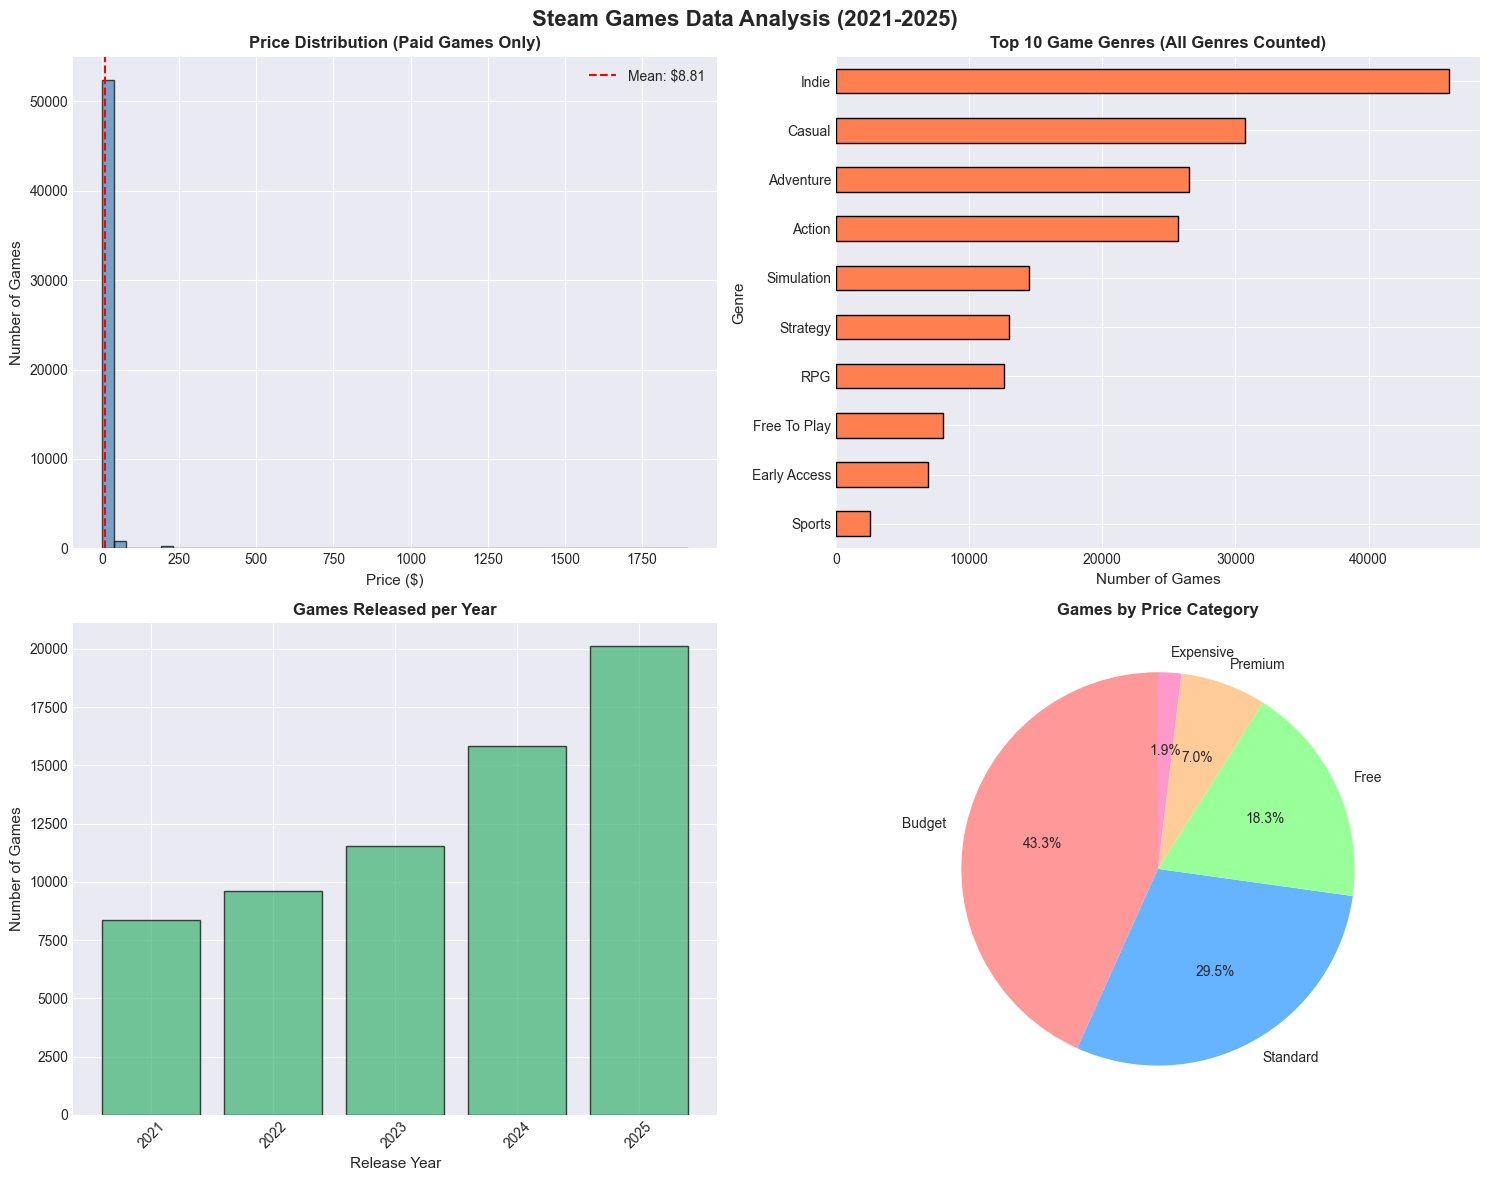

✓ Visualizations created successfully!


In [ ]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Steam Games Data Analysis (2021-2025)', fontsize=16, fontweight='bold')

# 1. Price Distribution
if 'price' in df_clean.columns:
    ax1 = axes[0, 0]
    price_data = df_clean[df_clean['price'] > 0]['price']  # Exclude free games
    ax1.hist(price_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Price ($)', fontsize=11)
    ax1.set_ylabel('Number of Games', fontsize=11)
    ax1.set_title('Price Distribution (Paid Games Only)', fontsize=12, fontweight='bold')
    ax1.axvline(price_data.mean(), color='red', linestyle='--', label=f'Mean: ${price_data.mean():.2f}')
    ax1.legend()

# 2. Top 10 Genres (using exploded method)
if 'genres_list' in df_clean.columns:
    ax2 = axes[0, 1]
    # Use exploded method to count ALL genres per game
    genre_expanded = df_clean.explode('genres_list')
    top_genres = genre_expanded['genres_list'].value_counts().head(10)
    top_genres.plot(kind='barh', ax=ax2, color='coral', edgecolor='black')
    ax2.set_xlabel('Number of Games', fontsize=11)
    ax2.set_ylabel('Genre', fontsize=11)
    ax2.set_title('Top 10 Game Genres (All Genres Counted)', fontsize=12, fontweight='bold')
    ax2.invert_yaxis()

# 3. Games by Release Year
if 'release_year' in df_clean.columns:
    ax3 = axes[1, 0]
    year_counts = df_clean['release_year'].value_counts().sort_index()
    ax3.bar(year_counts.index, year_counts.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Release Year', fontsize=11)
    ax3.set_ylabel('Number of Games', fontsize=11)
    ax3.set_title('Games Released per Year', fontsize=12, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)

# 4. Price Category Distribution
if 'price_category' in df_clean.columns:
    ax4 = axes[1, 1]
    price_cat_counts = df_clean['price_category'].value_counts()
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
    ax4.pie(price_cat_counts.values, labels=price_cat_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors)
    ax4.set_title('Games by Price Category', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualizations created successfully!")


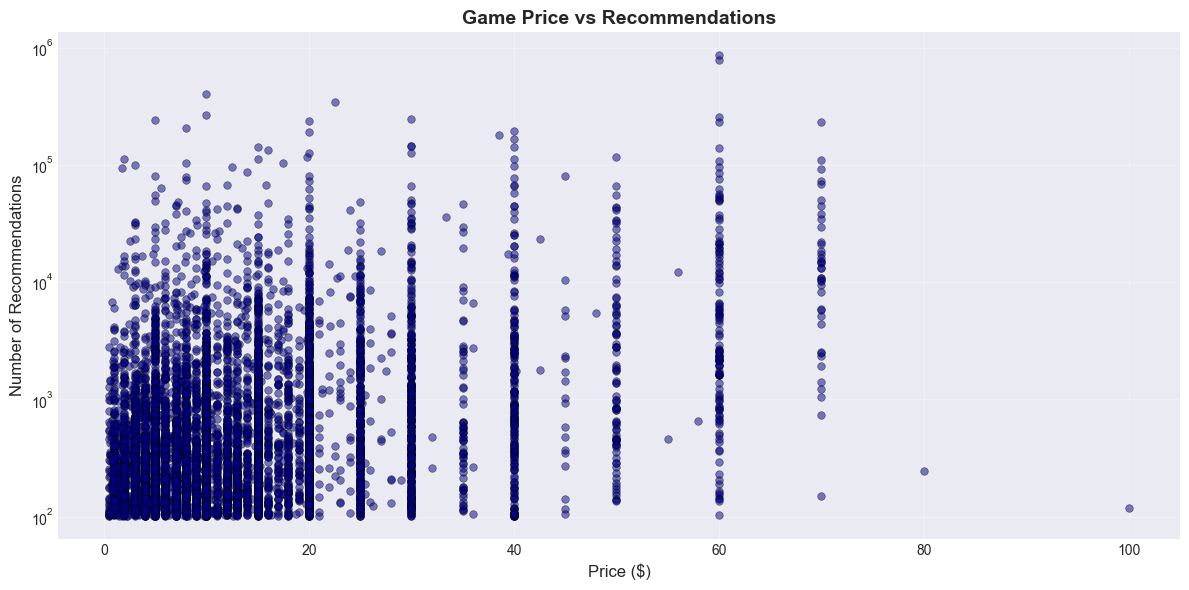

✓ Scatter plot created successfully!


In [ ]:
# Additional visualization: Recommendations vs Price scatter plot
fig, ax = plt.subplots(figsize=(12, 6))

if 'price' in df_clean.columns and 'recommendations' in df_clean.columns:
    # Filter data for better visualization
    scatter_data = df_clean[(df_clean['recommendations'] > 0) & (df_clean['price'] > 0)]
    
    ax.scatter(scatter_data['price'], scatter_data['recommendations'], 
               alpha=0.5, s=30, c='darkblue', edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Price ($)', fontsize=12)
    ax.set_ylabel('Number of Recommendations', fontsize=12)
    ax.set_title('Game Price vs Recommendations', fontsize=14, fontweight='bold')
    ax.set_yscale('log')  # Log scale for better visualization
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Scatter plot created successfully!")

### Additional Visualizations - Deep Dive Analysis

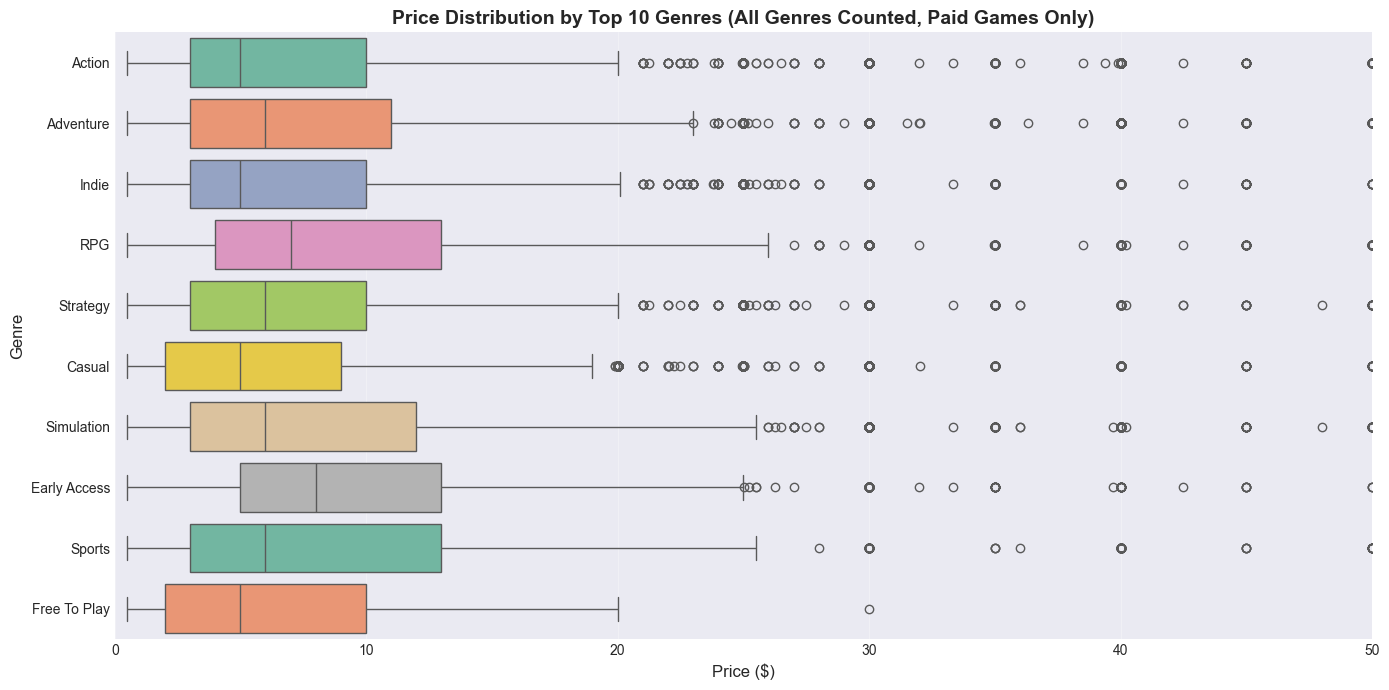

✓ Genre price distribution box plot created!


In [ ]:
# Visualization 3: Price Distribution by Top Genres (Box Plot)
fig, ax = plt.subplots(figsize=(14, 7))

if 'genres_list' in df_clean.columns and 'price' in df_clean.columns:
    # Use exploded method to get top 10 genres properly
    genre_expanded = df_clean.explode('genres_list')
    top_10_genres = genre_expanded['genres_list'].value_counts().head(10).index
    
    # Filter expanded data for paid games and top genres
    plot_data = genre_expanded[(genre_expanded['genres_list'].isin(top_10_genres)) & 
                                (genre_expanded['price'] > 0)]
    
    # Create box plot
    sns.boxplot(data=plot_data, y='genres_list', x='price', palette='Set2', ax=ax)
    ax.set_xlabel('Price ($)', fontsize=12)
    ax.set_ylabel('Genre', fontsize=12)
    ax.set_title('Price Distribution by Top 10 Genres (All Genres Counted, Paid Games Only)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlim(0, 50)  # Focus on 0-50 range for better visibility
    ax.grid(axis='x', alpha=0.3)
    
plt.tight_layout()
plt.show()

print("✓ Genre price distribution box plot created!")


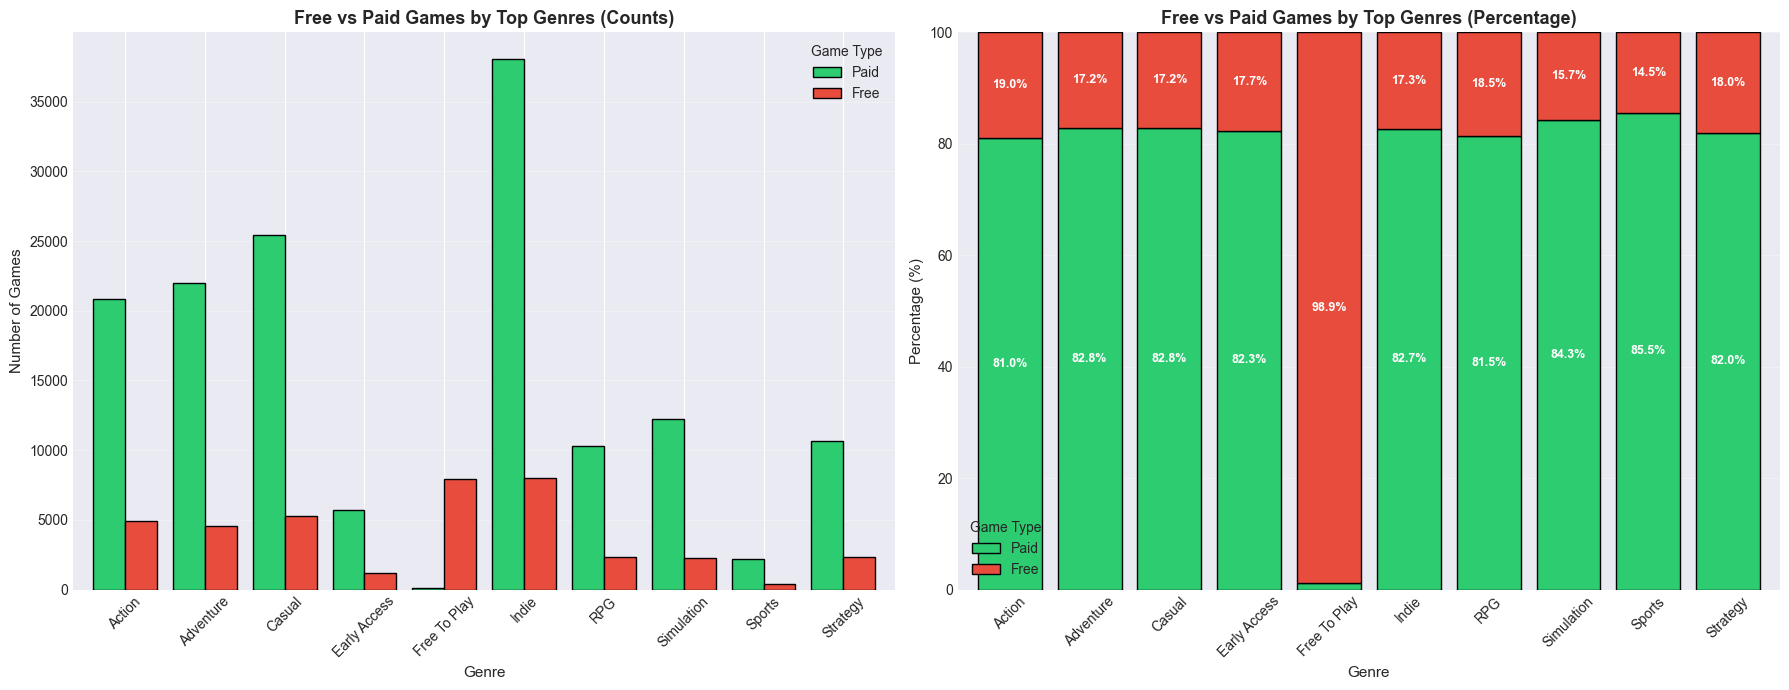

✓ Free vs Paid games comparison with percentages created!

Percentage breakdown by genre:
is_free          0     1
genres_list             
Action        81.0  19.0
Adventure     82.8  17.2
Casual        82.8  17.2
Early Access  82.3  17.7
Free To Play   1.1  98.9
Indie         82.7  17.3
RPG           81.5  18.5
Simulation    84.3  15.7
Sports        85.5  14.5
Strategy      82.0  18.0


In [ ]:
# Visualization 7: Free vs Paid Games by Top Genres with Percentage Analysis
if 'is_free' in df_clean.columns and 'genres_list' in df_clean.columns:
    # Get top 10 genres
    all_genres = []
    for genres in df_clean['genres_list']:
        all_genres.extend(genres)
    top_genres = pd.Series(all_genres).value_counts().head(10).index.tolist()
    
    # Expand genres and filter
    genre_expanded = df_clean.explode('genres_list')
    genre_expanded = genre_expanded[genre_expanded['genres_list'].isin(top_genres)]
    
    # Create comparison data
    comparison = genre_expanded.groupby(['genres_list', 'is_free']).size().unstack(fill_value=0)
    
    # Calculate percentages
    comparison_pct = comparison.div(comparison.sum(axis=1), axis=0) * 100
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Left plot: Absolute counts
    comparison.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], 
                    edgecolor='black', width=0.8)
    ax1.set_xlabel('Genre', fontsize=11)
    ax1.set_ylabel('Number of Games', fontsize=11)
    ax1.set_title('Free vs Paid Games by Top Genres (Counts)', 
                 fontsize=13, fontweight='bold')
    ax1.legend(['Paid', 'Free'], title='Game Type', fontsize=10)
    ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Right plot: Percentage comparison
    comparison_pct.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], 
                        edgecolor='black', width=0.8, stacked=True)
    ax2.set_xlabel('Genre', fontsize=11)
    ax2.set_ylabel('Percentage (%)', fontsize=11)
    ax2.set_title('Free vs Paid Games by Top Genres (Percentage)', 
                 fontsize=13, fontweight='bold')
    ax2.legend(['Paid', 'Free'], title='Game Type', fontsize=10)
    ax2.set_ylim(0, 100)
    ax2.grid(axis='y', alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    # Add percentage labels on stacked bars
    for i, genre in enumerate(comparison_pct.index):
        paid_pct = comparison_pct.iloc[i, 0]
        free_pct = comparison_pct.iloc[i, 1]
        if paid_pct > 5:  # Only show label if segment is large enough
            ax2.text(i, paid_pct/2, f'{paid_pct:.1f}%', ha='center', va='center', 
                    fontsize=9, fontweight='bold', color='white')
        if free_pct > 5:
            ax2.text(i, paid_pct + free_pct/2, f'{free_pct:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Free vs Paid games comparison with percentages created!")
    print("\nPercentage breakdown by genre:")
    print(comparison_pct.round(1))
else:
    print("Required columns not found")

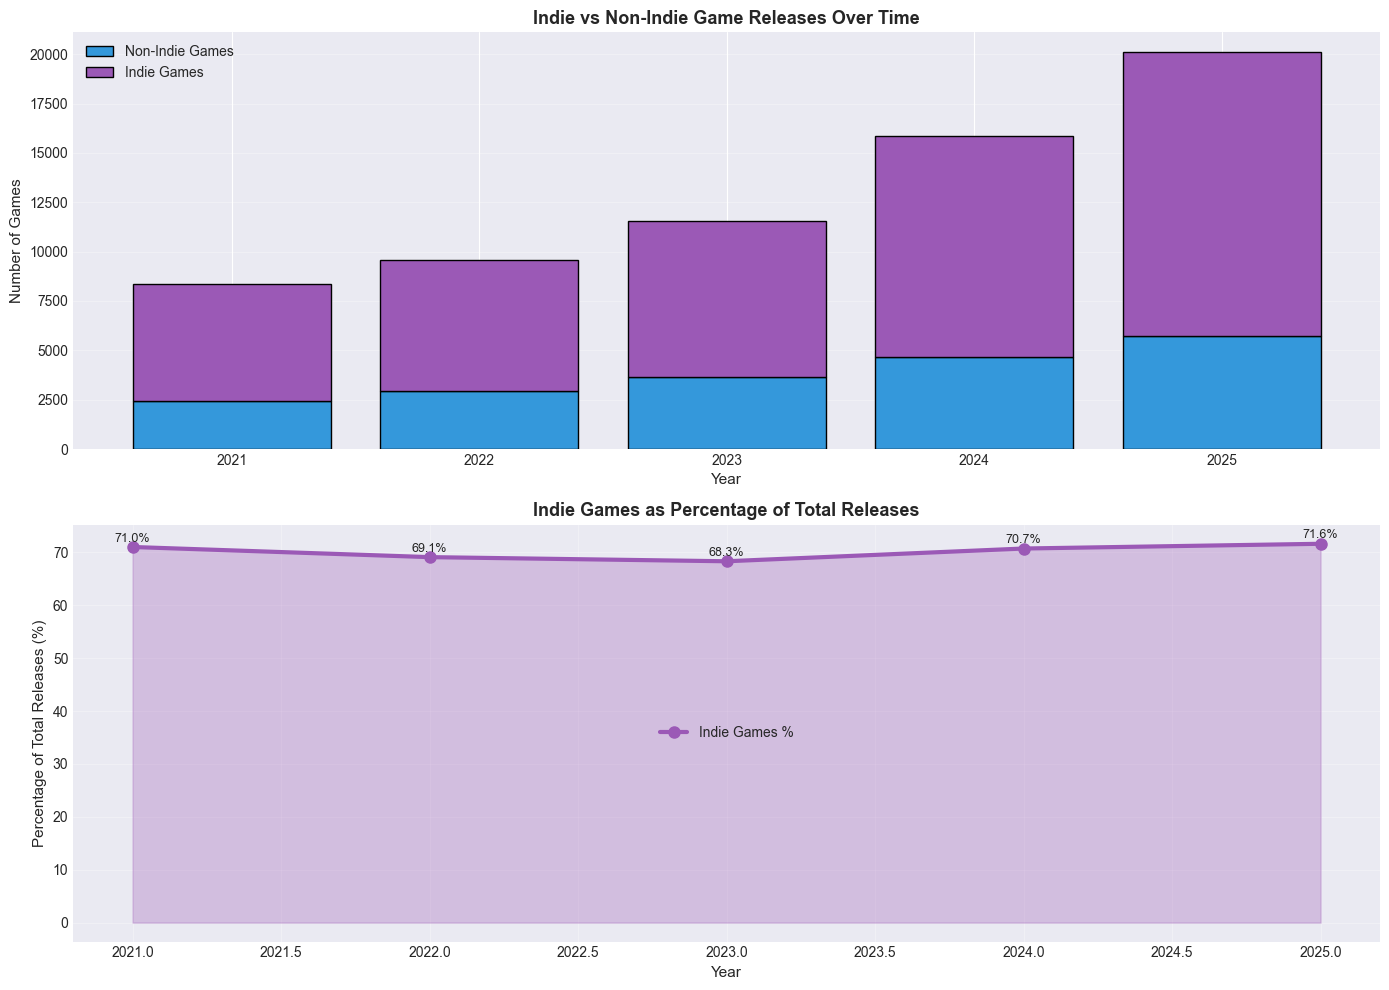

✓ Indie genre growth visualization created!

Indie games: 46058 (70.4% of total)


In [ ]:
# Visualization 8: Indie Genre Growth Over Years (Fixed - using genres_list)
if 'release_year' in df_clean.columns and 'genres_list' in df_clean.columns:
    # Filter indie games - Indie is a GENRE!
    df_indie = df_clean[df_clean['genres_list'].apply(lambda x: 'Indie' in x if isinstance(x, list) else False)]
    df_non_indie = df_clean[~df_clean['genres_list'].apply(lambda x: 'Indie' in x if isinstance(x, list) else False)]
    
    # Count by year
    indie_per_year = df_indie.groupby('release_year').size()
    non_indie_per_year = df_non_indie.groupby('release_year').size()
    total_per_year = df_clean.groupby('release_year').size()
    
    years = sorted(df_clean['release_year'].unique())
    indie_counts = [indie_per_year.get(year, 0) for year in years]
    non_indie_counts = [non_indie_per_year.get(year, 0) for year in years]
    indie_percentages = [(indie_per_year.get(year, 0) / total_per_year.get(year, 1)) * 100 for year in years]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Top plot: Stacked bar chart
    ax1.bar(years, non_indie_counts, label='Non-Indie Games', color='#3498db', edgecolor='black')
    ax1.bar(years, indie_counts, bottom=non_indie_counts, label='Indie Games', 
            color='#9b59b6', edgecolor='black')
    ax1.set_xlabel('Year', fontsize=11)
    ax1.set_ylabel('Number of Games', fontsize=11)
    ax1.set_title('Indie vs Non-Indie Game Releases Over Time', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3)
    
    # Bottom plot: Percentage trend line
    ax2.plot(years, indie_percentages, marker='o', linewidth=3, markersize=8, 
             color='#9b59b6', label='Indie Games %')
    ax2.fill_between(years, indie_percentages, alpha=0.3, color='#9b59b6')
    ax2.set_xlabel('Year', fontsize=11)
    ax2.set_ylabel('Percentage of Total Releases (%)', fontsize=11)
    ax2.set_title('Indie Games as Percentage of Total Releases', fontsize=13, fontweight='bold')
    ax2.grid(alpha=0.3)
    ax2.legend(fontsize=10)
    
    # Add value labels on line
    for year, pct in zip(years, indie_percentages):
        ax2.text(year, pct + 1, f'{pct:.1f}%', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Indie genre growth visualization created!")
    print(f"\nIndie games: {len(df_indie)} ({len(df_indie)/len(df_clean)*100:.1f}% of total)")

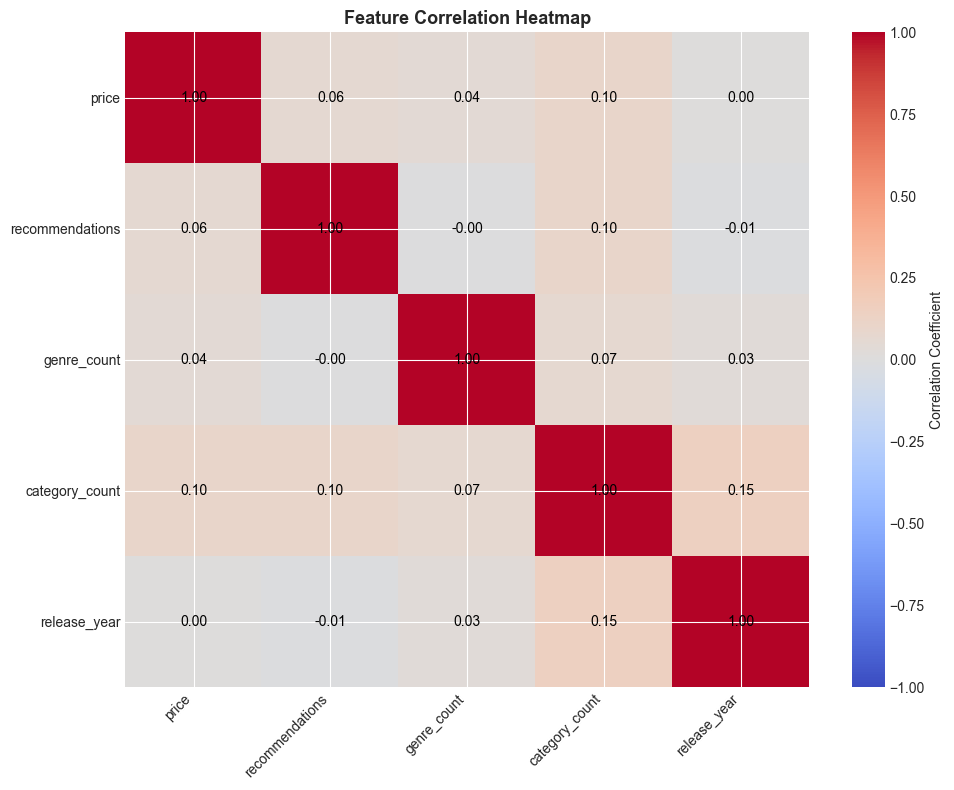

✓ Correlation heatmap created!

Key Insights:
- Strongest correlation: category_count vs release_year (0.146)


In [ ]:
# Visualization 10: Correlation Heatmap
# Select numerical columns for correlation analysis
numerical_cols = ['price', 'recommendations', 'genre_count', 'category_count', 'release_year']
available_cols = [col for col in numerical_cols if col in df_clean.columns]

if len(available_cols) >= 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Calculate correlation matrix
    corr_matrix = df_clean[available_cols].corr()
    
    # Create heatmap
    im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    
    # Set ticks and labels
    ax.set_xticks(range(len(available_cols)))
    ax.set_yticks(range(len(available_cols)))
    ax.set_xticklabels(available_cols, rotation=45, ha='right')
    ax.set_yticklabels(available_cols)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Correlation Coefficient', fontsize=10)
    
    # Add correlation values as text
    for i in range(len(available_cols)):
        for j in range(len(available_cols)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', color='black', fontsize=10)
    
    ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("✓ Correlation heatmap created!")
    print(f"\nKey Insights:")
    
    # Find strongest correlations (excluding diagonal)
    corr_pairs = []
    for i in range(len(available_cols)):
        for j in range(i+1, len(available_cols)):
            corr_pairs.append((available_cols[i], available_cols[j], corr_matrix.iloc[i, j]))
    
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    print(f"- Strongest correlation: {corr_pairs[0][0]} vs {corr_pairs[0][1]} ({corr_pairs[0][2]:.3f})")
else:
    print("Not enough numerical columns for correlation analysis")

### 🎯 Comprehensive Indie vs Non-Indie Comparison Analysis


ANALYSIS 2: SUCCESS METRICS (RECOMMENDATIONS)

⭐ RECOMMENDATIONS STATISTICS:
   Metric                         Indie       Non-Indie
   -------------------------------------------------------
   Mean                             240             652
   Median                             0               0
   Max                          401,836         862,487
   Std Dev                        4,296          10,891

🎯 SUCCESS RATE BREAKDOWN:
   Threshold                    Indie %     Non-Indie %
   -------------------------------------------------------
   > 0                           100.0%          100.0%
   >= 100                         11.4%           13.9%
   >= 1K                           2.5%            4.4%
   >= 5K                           0.7%            1.6%
   >= 10K                          0.4%            0.9%


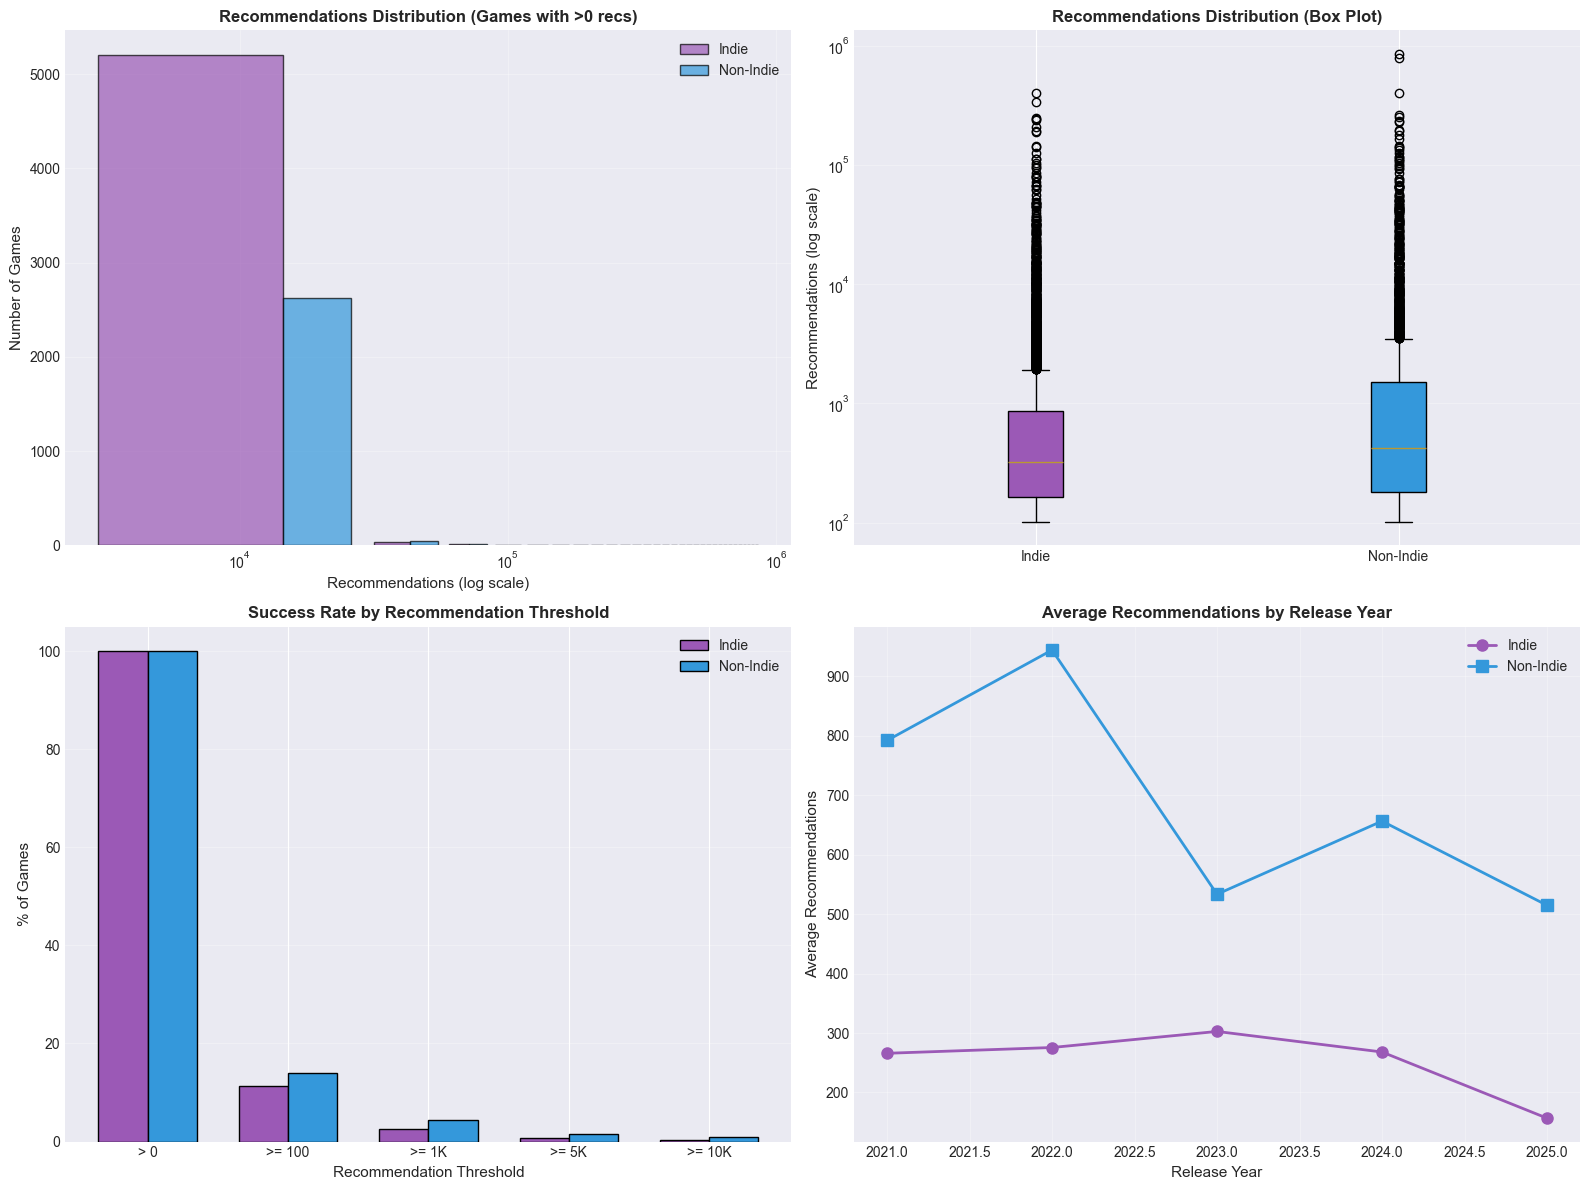


✓ Success metrics visualizations created!


In [ ]:
# 1. SUCCESS METRICS: Recommendations Analysis
print("\n" + "="*80)
print("ANALYSIS 2: SUCCESS METRICS (RECOMMENDATIONS)")
print("="*80)

if {'is_indie', 'recommendations'}.issubset(df_clean.columns):
    df_indie, df_non_indie = split_indie_segments(df_clean)
    
    # Pre-compute recommendation arrays for faster reuse
    indie_recs = df_indie['recommendations'].to_numpy()
    non_indie_recs = df_non_indie['recommendations'].to_numpy()
    indie_recs_nonzero = indie_recs[indie_recs > 0]
    non_indie_recs_nonzero = non_indie_recs[non_indie_recs > 0]
    
    # Calculate statistics
    indie_rec_stats = df_indie['recommendations'].describe()
    non_indie_rec_stats = df_non_indie['recommendations'].describe()
    
    # Success thresholds
    thresholds_display = ['> 0', '>= 100', '>= 1K', '>= 5K', '>= 10K']
    thresholds_values = [0, 100, 1000, 5000, 10000]
    
    print(f"\n⭐ RECOMMENDATIONS STATISTICS:")
    print(f"   {'Metric':<20} {'Indie':>15} {'Non-Indie':>15}")
    print(f"   {'-'*55}")
    print(f"   {'Mean':<20} {indie_rec_stats['mean']:>15,.0f} {non_indie_rec_stats['mean']:>15,.0f}")
    print(f"   {'Median':<20} {indie_rec_stats['50%']:>15,.0f} {non_indie_rec_stats['50%']:>15,.0f}")
    print(f"   {'Max':<20} {indie_rec_stats['max']:>15,.0f} {non_indie_rec_stats['max']:>15,.0f}")
    print(f"   {'Std Dev':<20} {indie_rec_stats['std']:>15,.0f} {non_indie_rec_stats['std']:>15,.0f}")
    
    print(f"\n🎯 SUCCESS RATE BREAKDOWN:")
    print(f"   {'Threshold':<20} {'Indie %':>15} {'Non-Indie %':>15}")
    print(f"   {'-'*55}")
    indie_success = compute_threshold_share(df_indie, 'recommendations', thresholds_values)
    non_indie_success = compute_threshold_share(df_non_indie, 'recommendations', thresholds_values)
    for label, indie_data, non_indie_data in zip(thresholds_display, indie_success, non_indie_success):
        print(f"   {label:<20} {indie_data['share_pct']:>14.1f}% {non_indie_data['share_pct']:>14.1f}%")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribution histogram (log scale) with fewer bins for speed
    ax1 = axes[0, 0]
    ax1.hist([indie_recs_nonzero, non_indie_recs_nonzero], bins=30, 
             label=['Indie', 'Non-Indie'], color=['#9b59b6', '#3498db'], 
             alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Recommendations (log scale)', fontsize=11)
    ax1.set_ylabel('Number of Games', fontsize=11)
    ax1.set_title('Recommendations Distribution (Games with >0 recs)', fontsize=12, fontweight='bold')
    ax1.set_xscale('log')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 2. Box plot comparison using precomputed arrays
    ax2 = axes[0, 1]
    box_data = [indie_recs_nonzero, non_indie_recs_nonzero]
    bp = ax2.boxplot(box_data, labels=['Indie', 'Non-Indie'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#9b59b6')
    bp['boxes'][1].set_facecolor('#3498db')
    ax2.set_ylabel('Recommendations (log scale)', fontsize=11)
    ax2.set_title('Recommendations Distribution (Box Plot)', fontsize=12, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Success rate comparison (vectorized computations)
    ax3 = axes[1, 0]
    indie_success_vals = [entry['share_pct'] for entry in indie_success]
    non_indie_success_vals = [entry['share_pct'] for entry in non_indie_success]
    
    x = np.arange(len(thresholds_display))
    width = 0.35
    
    ax3.bar(x - width/2, indie_success_vals, width, label='Indie', color='#9b59b6', edgecolor='black')
    ax3.bar(x + width/2, non_indie_success_vals, width, label='Non-Indie', color='#3498db', edgecolor='black')
    ax3.set_xlabel('Recommendation Threshold', fontsize=11)
    ax3.set_ylabel('% of Games', fontsize=11)
    ax3.set_title('Success Rate by Recommendation Threshold', fontsize=12, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(thresholds_display)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Average recommendations by release year
    ax4 = axes[1, 1]
    if 'release_year' in df_clean.columns:
        indie_rec_by_year = df_indie.groupby('release_year')['recommendations'].mean()
        non_indie_rec_by_year = df_non_indie.groupby('release_year')['recommendations'].mean()
        
        years = sorted(df_clean['release_year'].unique())
        indie_avg = [indie_rec_by_year.get(year, 0) for year in years]
        non_indie_avg = [non_indie_rec_by_year.get(year, 0) for year in years]
        
        ax4.plot(years, indie_avg, marker='o', linewidth=2, markersize=8, 
                color='#9b59b6', label='Indie')
        ax4.plot(years, non_indie_avg, marker='s', linewidth=2, markersize=8,
                color='#3498db', label='Non-Indie')
        ax4.set_xlabel('Release Year', fontsize=11)
        ax4.set_ylabel('Average Recommendations', fontsize=11)
        ax4.set_title('Average Recommendations by Release Year', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Success metrics visualizations created!")
else:
    print("Required columns for recommendations analysis are missing")


ANALYSIS 3: MARKET STRATEGIES COMPARISON

🎮 MARKET STRATEGY ADOPTION:
   Strategy                 Indie Count    Indie %    Non-Indie Count   Non-Indie %
   --------------------------------------------------------------------------------
   Free-to-Play                   7,982      17.3%              3,966         20.4%
   Multiplayer                    6,576      14.3%              3,776         19.5%
   Early Access                       0       0.0%                  0          0.0%


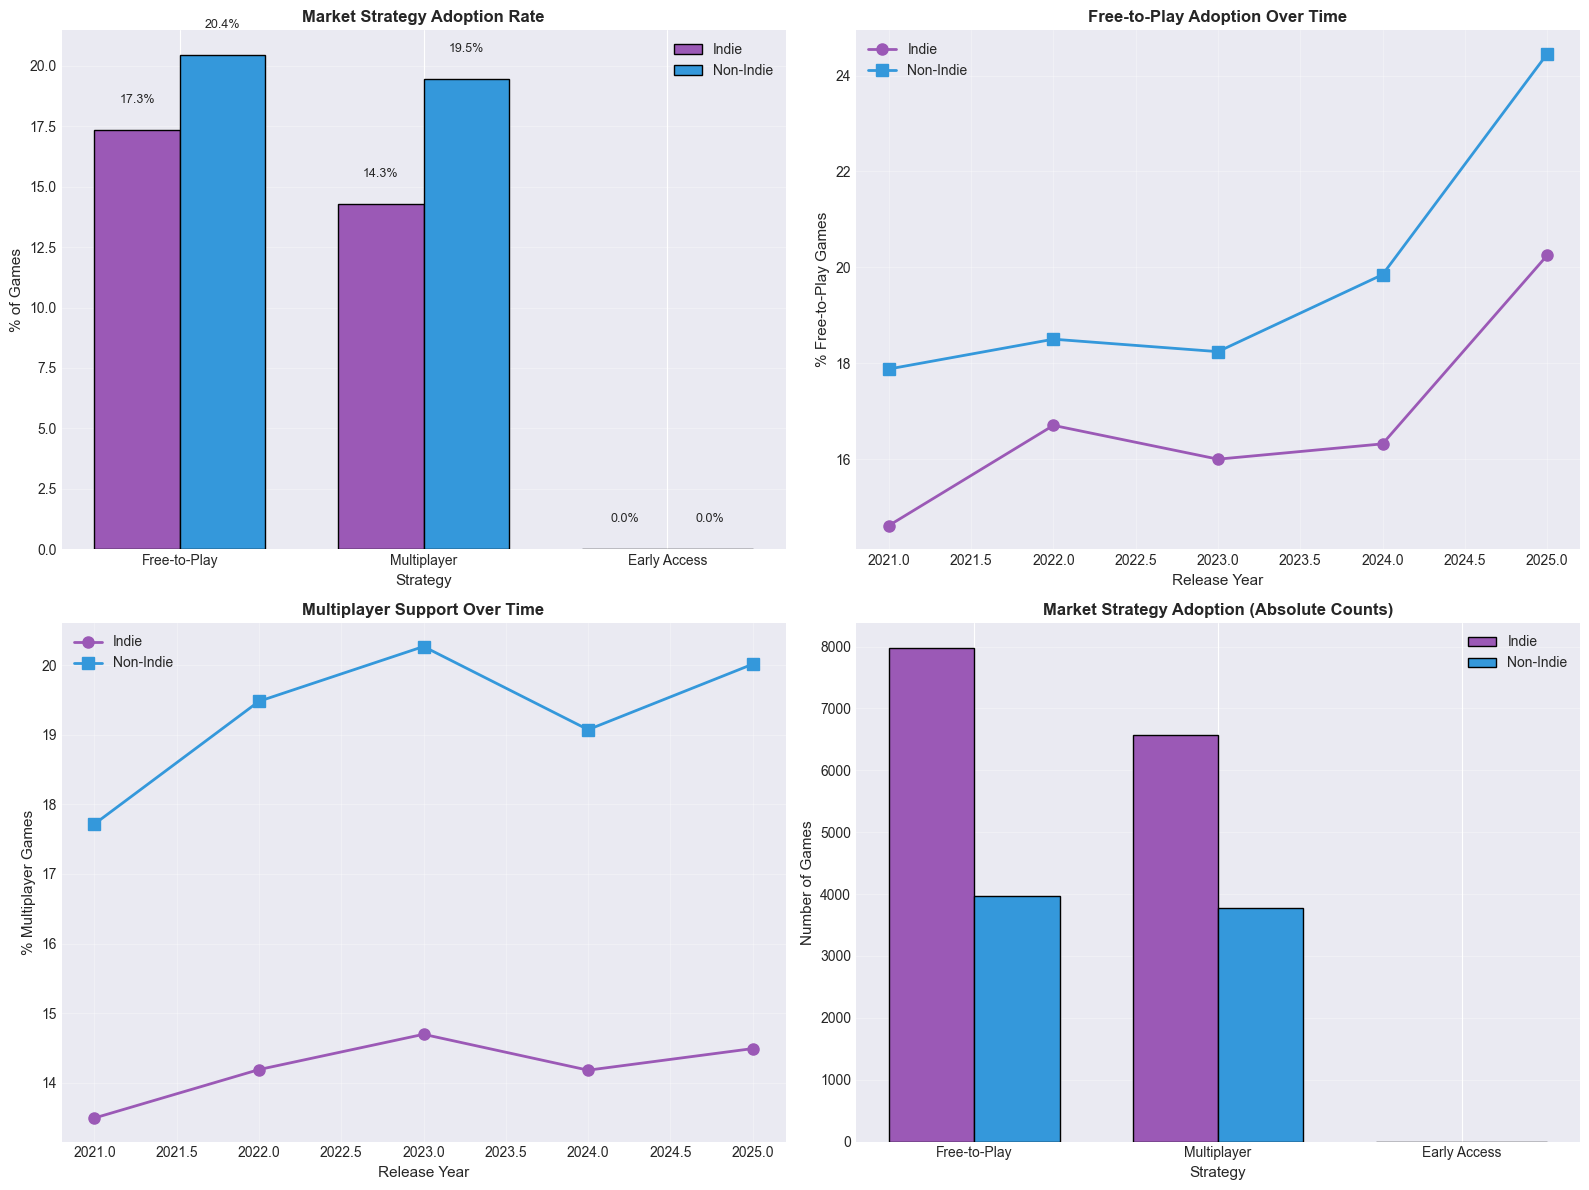


✓ Market strategies analysis completed!


In [ ]:
# 2. MARKET STRATEGIES: Free-to-Play, Multiplayer, Early Access
print("\n" + "="*80)
print("ANALYSIS 3: MARKET STRATEGIES COMPARISON")
print("="*80)

if 'is_indie' in df_clean.columns:
    df_indie, df_non_indie = split_indie_segments(df_clean)
    
    # Calculate strategy metrics
    strategies = {
        'Free-to-Play': 'is_free',
        'Multiplayer': 'is_multiplayer',
        'Early Access': 'is_early_access'
    }
    
    print(f"\n🎮 MARKET STRATEGY ADOPTION:")
    print(f"   {'Strategy':<20} {'Indie Count':>15} {'Indie %':>10} {'Non-Indie Count':>18} {'Non-Indie %':>13}")
    print(f"   {'-'*80}")
    
    strategy_data = {}
    for strategy_name, column in strategies.items():
        if column in df_clean.columns:
            indie_count = (df_indie[column] == 1).sum()
            indie_pct = indie_count / len(df_indie) * 100 if len(df_indie) else 0
            non_indie_count = (df_non_indie[column] == 1).sum()
            non_indie_pct = non_indie_count / len(df_non_indie) * 100 if len(df_non_indie) else 0
            
            print(f"   {strategy_name:<20} {indie_count:>15,} {indie_pct:>9.1f}% {non_indie_count:>18,} {non_indie_pct:>12.1f}%")
            
            strategy_data[strategy_name] = {
                'indie_pct': indie_pct,
                'non_indie_pct': non_indie_pct,
                'indie_count': indie_count,
                'non_indie_count': non_indie_count
            }
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Strategy adoption comparison (percentage)
    ax1 = axes[0, 0]
    strategy_names = list(strategy_data.keys())
    indie_pcts = [strategy_data[s]['indie_pct'] for s in strategy_names]
    non_indie_pcts = [strategy_data[s]['non_indie_pct'] for s in strategy_names]
    
    x = np.arange(len(strategy_names))
    width = 0.35
    
    ax1.bar(x - width/2, indie_pcts, width, label='Indie', color='#9b59b6', edgecolor='black')
    ax1.bar(x + width/2, non_indie_pcts, width, label='Non-Indie', color='#3498db', edgecolor='black')
    ax1.set_xlabel('Strategy', fontsize=11)
    ax1.set_ylabel('% of Games', fontsize=11)
    ax1.set_title('Market Strategy Adoption Rate', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(strategy_names)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Add percentage labels
    for i in range(len(strategy_names)):
        ax1.text(i - width/2, indie_pcts[i] + 1, f'{indie_pcts[i]:.1f}%', 
                ha='center', va='bottom', fontsize=9)
        ax1.text(i + width/2, non_indie_pcts[i] + 1, f'{non_indie_pcts[i]:.1f}%',
                ha='center', va='bottom', fontsize=9)
    
    # 2. Strategy adoption over time (Free-to-Play)
    ax2 = axes[0, 1]
    if 'release_year' in df_clean.columns and 'is_free' in df_clean.columns:
        years = sorted(df_clean['release_year'].unique())
        
        indie_free_by_year = df_indie.groupby('release_year')['is_free'].mean() * 100
        non_indie_free_by_year = df_non_indie.groupby('release_year')['is_free'].mean() * 100
        
        indie_free_pct = [indie_free_by_year.get(year, 0) for year in years]
        non_indie_free_pct = [non_indie_free_by_year.get(year, 0) for year in years]
        
        ax2.plot(years, indie_free_pct, marker='o', linewidth=2, markersize=8,
                color='#9b59b6', label='Indie')
        ax2.plot(years, non_indie_free_pct, marker='s', linewidth=2, markersize=8,
                color='#3498db', label='Non-Indie')
        ax2.set_xlabel('Release Year', fontsize=11)
        ax2.set_ylabel('% Free-to-Play Games', fontsize=11)
        ax2.set_title('Free-to-Play Adoption Over Time', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(alpha=0.3)
    
    # 3. Strategy adoption over time (Multiplayer)
    ax3 = axes[1, 0]
    if 'release_year' in df_clean.columns and 'is_multiplayer' in df_clean.columns:
        indie_mp_by_year = df_indie.groupby('release_year')['is_multiplayer'].mean() * 100
        non_indie_mp_by_year = df_non_indie.groupby('release_year')['is_multiplayer'].mean() * 100
        
        years = sorted(df_clean['release_year'].unique())
        indie_mp_pct = [indie_mp_by_year.get(year, 0) for year in years]
        non_indie_mp_pct = [non_indie_mp_by_year.get(year, 0) for year in years]
        
        ax3.plot(years, indie_mp_pct, marker='o', linewidth=2, markersize=8,
                color='#9b59b6', label='Indie')
        ax3.plot(years, non_indie_mp_pct, marker='s', linewidth=2, markersize=8,
                color='#3498db', label='Non-Indie')
        ax3.set_xlabel('Release Year', fontsize=11)
        ax3.set_ylabel('% Multiplayer Games', fontsize=11)
        ax3.set_title('Multiplayer Support Over Time', fontsize=12, fontweight='bold')
        ax3.legend()
        ax3.grid(alpha=0.3)
    
    # 4. Combined strategy analysis (stacked bar)
    ax4 = axes[1, 1]
    indie_counts = [strategy_data[s]['indie_count'] for s in strategy_names]
    non_indie_counts = [strategy_data[s]['non_indie_count'] for s in strategy_names]
    
    x = np.arange(len(strategy_names))
    width = 0.35
    
    ax4.bar(x - width/2, indie_counts, width, label='Indie', color='#9b59b6', edgecolor='black')
    ax4.bar(x + width/2, non_indie_counts, width, label='Non-Indie', color='#3498db', edgecolor='black')
    ax4.set_xlabel('Strategy', fontsize=11)
    ax4.set_ylabel('Number of Games', fontsize=11)
    ax4.set_title('Market Strategy Adoption (Absolute Counts)', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(strategy_names)
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Market strategies analysis completed!")
else:
    print("Required columns for strategy analysis are missing")


ANALYSIS 4: GENRE DIVERSITY

🎯 GENRE DIVERSITY STATISTICS:
   Metric                      Indie    Non-Indie
   --------------------------------------------------
   Mean genres/game             3.27         2.06
   Median genres/game              3            2
   Max genres/game                11           11

📊 GENRE COUNT DISTRIBUTION:
   # of Genres               Indie %     Non-Indie %
   --------------------------------------------------
   1                            3.6%           38.2%
   2                           24.8%           33.4%
   3                           34.8%           18.5%
   4                           22.2%            6.3%
   5                            9.5%            2.5%
   6                            3.3%            0.9%
   7                            1.0%            0.3%
   8                            0.4%            0.1%
   9                            0.3%            0.0%
   10                           0.0%            0.0%
   11               

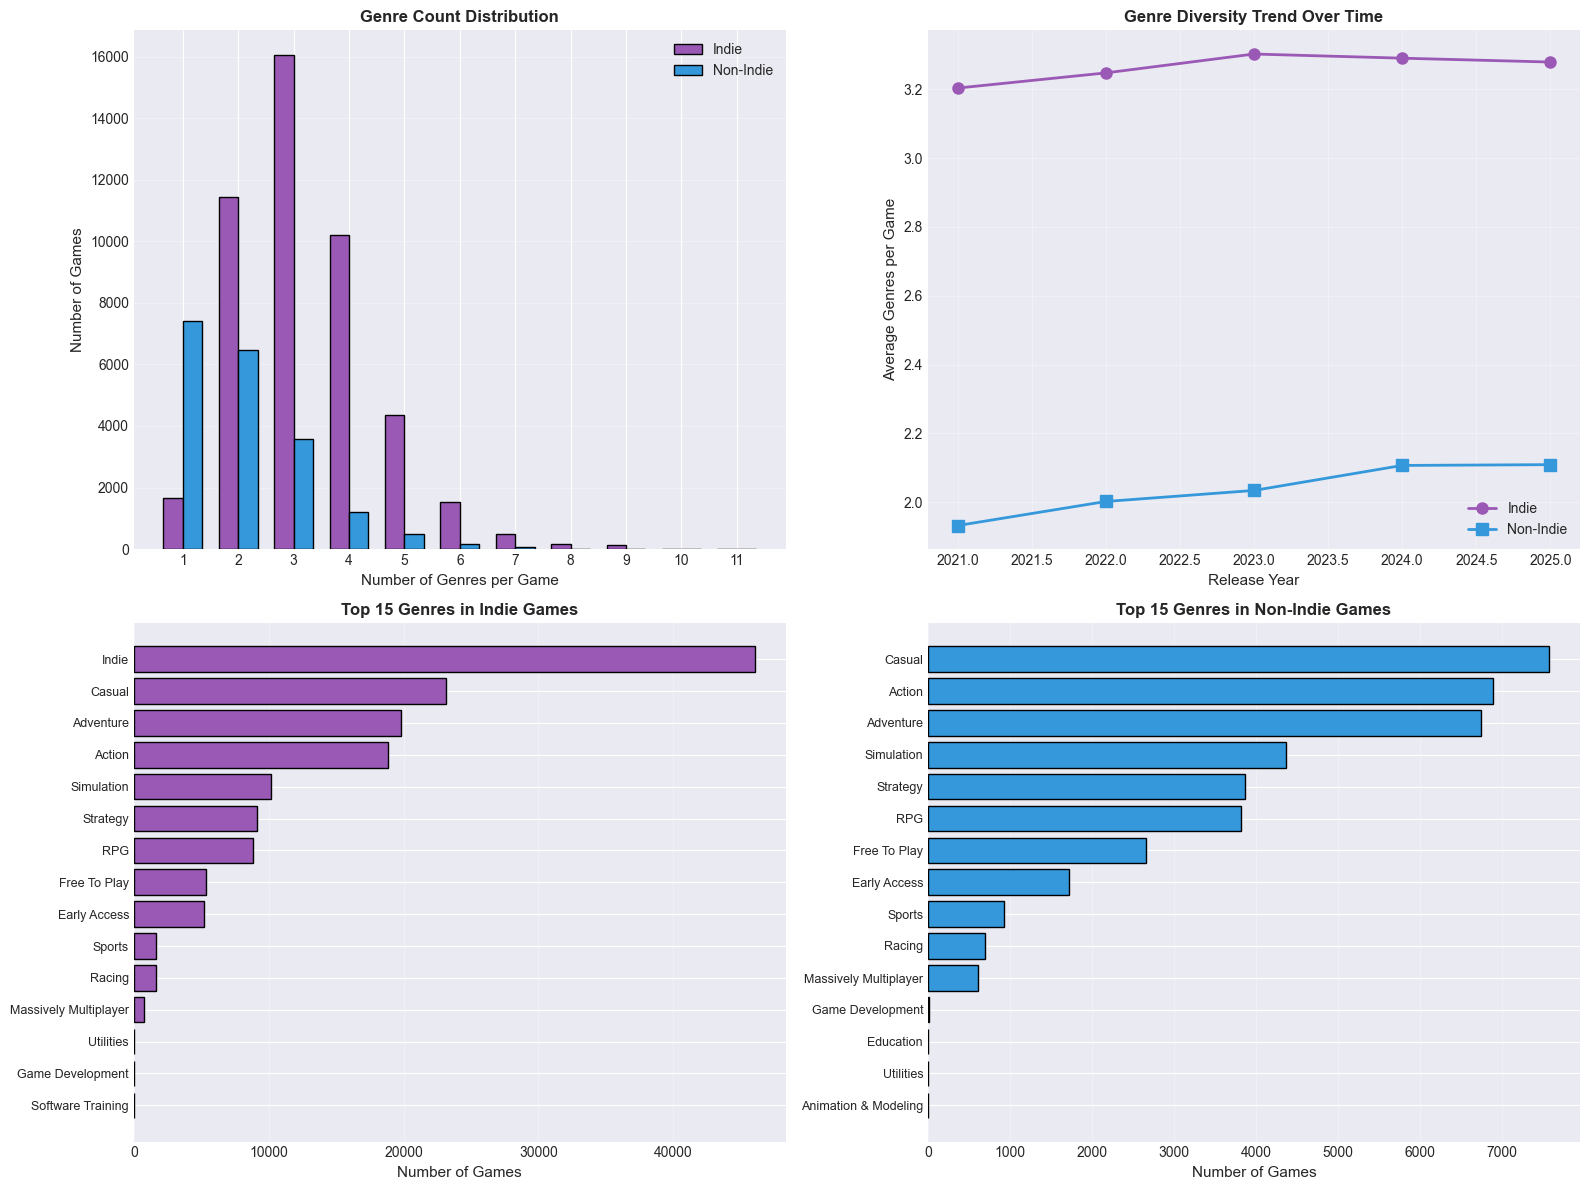


✓ Genre diversity analysis completed!


In [ ]:
# 3. GENRE DIVERSITY ANALYSIS
print("\n" + "="*80)
print("ANALYSIS 4: GENRE DIVERSITY")
print("="*80)

if {'is_indie', 'genre_count'}.issubset(df_clean.columns):
    df_indie, df_non_indie = split_indie_segments(df_clean)
    
    # Genre count statistics
    indie_genre_stats = df_indie['genre_count'].describe()
    non_indie_genre_stats = df_non_indie['genre_count'].describe()
    
    print(f"\n🎯 GENRE DIVERSITY STATISTICS:")
    print(f"   {'Metric':<20} {'Indie':>12} {'Non-Indie':>12}")
    print(f"   {'-'*50}")
    print(f"   {'Mean genres/game':<20} {indie_genre_stats['mean']:>12.2f} {non_indie_genre_stats['mean']:>12.2f}")
    print(f"   {'Median genres/game':<20} {indie_genre_stats['50%']:>12.0f} {non_indie_genre_stats['50%']:>12.0f}")
    print(f"   {'Max genres/game':<20} {indie_genre_stats['max']:>12.0f} {non_indie_genre_stats['max']:>12.0f}")
    
    # Genre count distribution
    print(f"\n📊 GENRE COUNT DISTRIBUTION:")
    print(f"   {'# of Genres':<20} {'Indie %':>12} {'Non-Indie %':>15}")
    print(f"   {'-'*50}")
    for count in sorted(df_clean['genre_count'].unique()):
        if count > 0:
            indie_pct = (df_indie['genre_count'] == count).sum() / len(df_indie) * 100
            non_indie_pct = (df_non_indie['genre_count'] == count).sum() / len(df_non_indie) * 100
            print(f"   {int(count):<20} {indie_pct:>11.1f}% {non_indie_pct:>14.1f}%")
    
    # Top genre combinations
    print(f"\n🎮 TOP 10 GENRE COMBINATIONS (Indie):")
    indie_genre_combos = df_indie['genres_list'].apply(lambda x: ', '.join(sorted(x)) if isinstance(x, list) else '')
    top_indie_combos = indie_genre_combos.value_counts().head(10)
    for i, (combo, count) in enumerate(top_indie_combos.items(), 1):
        print(f"   {i:2d}. {combo:<50} ({count:>5,} games)")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Genre count distribution
    ax1 = axes[0, 0]
    genre_counts = sorted(df_clean['genre_count'].unique())
    indie_dist = [(df_indie['genre_count'] == c).sum() for c in genre_counts]
    non_indie_dist = [(df_non_indie['genre_count'] == c).sum() for c in genre_counts]
    
    x = np.arange(len(genre_counts))
    width = 0.35
    
    ax1.bar(x - width/2, indie_dist, width, label='Indie', color='#9b59b6', edgecolor='black')
    ax1.bar(x + width/2, non_indie_dist, width, label='Non-Indie', color='#3498db', edgecolor='black')
    ax1.set_xlabel('Number of Genres per Game', fontsize=11)
    ax1.set_ylabel('Number of Games', fontsize=11)
    ax1.set_title('Genre Count Distribution', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([int(c) for c in genre_counts])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Average genre count by release year
    ax2 = axes[0, 1]
    if 'release_year' in df_clean.columns:
        years = sorted(df_clean['release_year'].unique())
        indie_genre_by_year = df_indie.groupby('release_year')['genre_count'].mean()
        non_indie_genre_by_year = df_non_indie.groupby('release_year')['genre_count'].mean()
        
        indie_avg = [indie_genre_by_year.get(year, 0) for year in years]
        non_indie_avg = [non_indie_genre_by_year.get(year, 0) for year in years]
        
        ax2.plot(years, indie_avg, marker='o', linewidth=2, markersize=8,
                color='#9b59b6', label='Indie')
        ax2.plot(years, non_indie_avg, marker='s', linewidth=2, markersize=8,
                color='#3498db', label='Non-Indie')
        ax2.set_xlabel('Release Year', fontsize=11)
        ax2.set_ylabel('Average Genres per Game', fontsize=11)
        ax2.set_title('Genre Diversity Trend Over Time', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(alpha=0.3)
    
    # 3. Top 15 genres for Indie (using explode)
    ax3 = axes[1, 0]
    indie_expanded = df_indie.explode('genres_list')
    top_indie_genres = indie_expanded['genres_list'].value_counts().head(15)
    
    ax3.barh(range(len(top_indie_genres)), top_indie_genres.values, 
            color='#9b59b6', edgecolor='black')
    ax3.set_yticks(range(len(top_indie_genres)))
    ax3.set_yticklabels(top_indie_genres.index, fontsize=9)
    ax3.set_xlabel('Number of Games', fontsize=11)
    ax3.set_title('Top 15 Genres in Indie Games', fontsize=12, fontweight='bold')
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)
    
    # 4. Top 15 genres for Non-Indie (using explode)
    ax4 = axes[1, 1]
    non_indie_expanded = df_non_indie.explode('genres_list')
    top_non_indie_genres = non_indie_expanded['genres_list'].value_counts().head(15)
    
    ax4.barh(range(len(top_non_indie_genres)), top_non_indie_genres.values,
            color='#3498db', edgecolor='black')
    ax4.set_yticks(range(len(top_non_indie_genres)))
    ax4.set_yticklabels(top_non_indie_genres.index, fontsize=9)
    ax4.set_xlabel('Number of Games', fontsize=11)
    ax4.set_title('Top 15 Genres in Non-Indie Games', fontsize=12, fontweight='bold')
    ax4.invert_yaxis()
    ax4.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Genre diversity analysis completed!")
else:
    print("Required columns for genre diversity analysis are missing")


ANALYSIS 5: CATEGORY PATTERNS

🏆 TOP 15 INDIE-DOMINATED CATEGORIES:
   Category                             Indie Count   Non-Indie Count    Indie %
   --------------------------------------------------------------------------------
   Stats                                      1,894                 0     100.0%
   Save Anytime                               2,186                 0     100.0%
   Mouse Only Option                          1,953                 0     100.0%
   Steam Leaderboards                         3,257               947      77.5%
   Custom Volume Controls                     4,026             1,248      76.3%
   Playable without Timed Input               3,923             1,292      75.2%
   Steam Achievements                        23,295             7,766      75.0%
   Stereo Sound                               2,297               817      73.8%
   Full controller support                   10,750             3,877      73.5%
   Steam Cloud                       

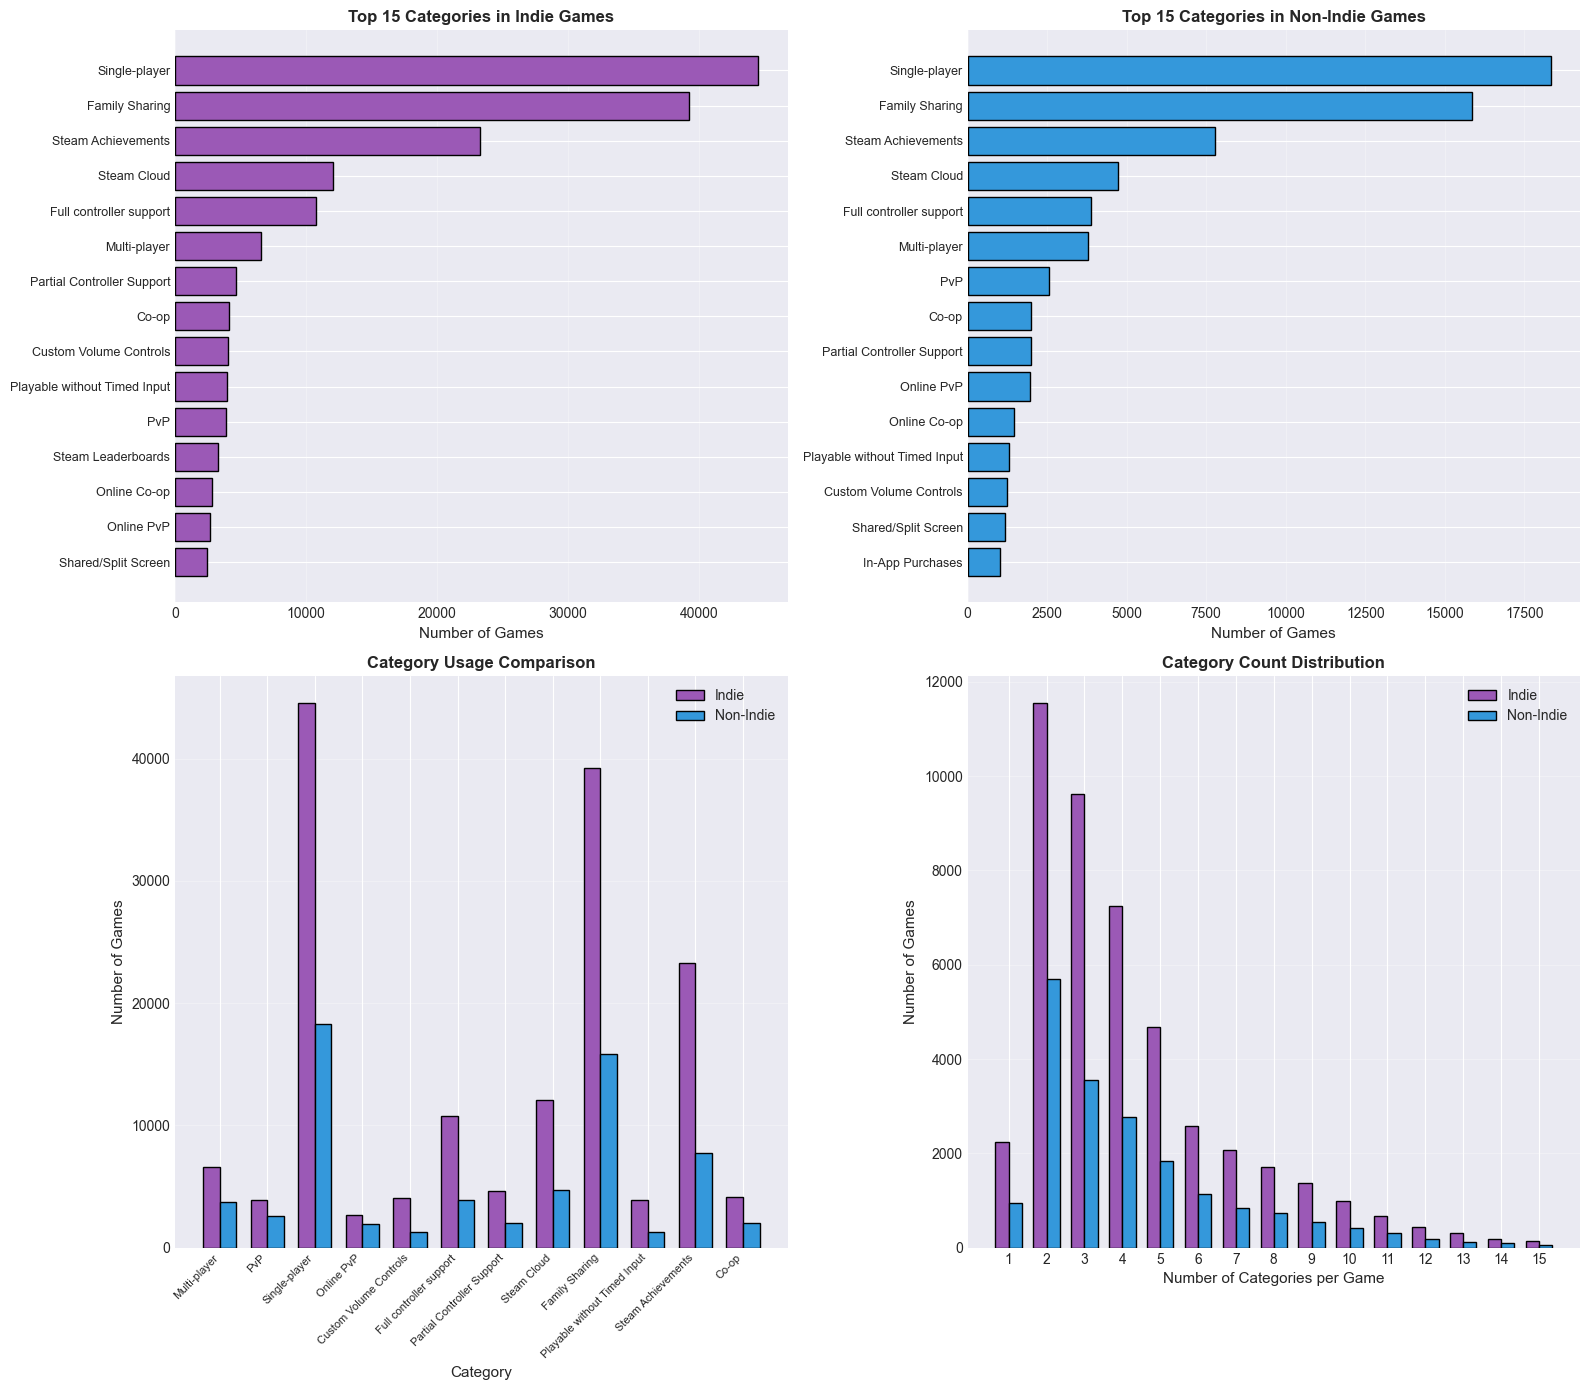


✓ Category patterns analysis completed!


In [ ]:
# 5. CATEGORY PATTERNS ANALYSIS
print("\n" + "="*80)
print("ANALYSIS 5: CATEGORY PATTERNS")
print("="*80)

if {'is_indie', 'categories_list'}.issubset(df_clean.columns):
    df_indie, df_non_indie = split_indie_segments(df_clean)
    
    # Explode categories
    indie_cat_expanded = df_indie.explode('categories_list')
    non_indie_cat_expanded = df_non_indie.explode('categories_list')
    
    # Top categories
    top_indie_cats = indie_cat_expanded['categories_list'].value_counts().head(20)
    top_non_indie_cats = non_indie_cat_expanded['categories_list'].value_counts().head(20)
    
    # Find indie-dominated and non-indie dominated categories
    all_cats = set(top_indie_cats.index) | set(top_non_indie_cats.index)
    
    print(f"\n🏆 TOP 15 INDIE-DOMINATED CATEGORIES:")
    print(f"   {'Category':<35} {'Indie Count':>12} {'Non-Indie Count':>17} {'Indie %':>10}")
    print(f"   {'-'*80}")
    
    cat_comparison = []
    for cat in all_cats:
        indie_count = top_indie_cats.get(cat, 0)
        non_indie_count = top_non_indie_cats.get(cat, 0)
        total = indie_count + non_indie_count
        if total > 0:
            indie_pct = (indie_count / total) * 100
            cat_comparison.append((cat, indie_count, non_indie_count, indie_pct))
    
    # Sort by indie percentage
    cat_comparison.sort(key=lambda x: x[3], reverse=True)
    
    for cat, indie_c, non_indie_c, indie_pct in cat_comparison[:15]:
        print(f"   {cat:<35} {indie_c:>12,} {non_indie_c:>17,} {indie_pct:>9.1f}%")
    
    print(f"\n🏆 TOP 15 NON-INDIE-DOMINATED CATEGORIES:")
    print(f"   {'Category':<35} {'Indie Count':>12} {'Non-Indie Count':>17} {'Non-Indie %':>13}")
    print(f"   {'-'*80}")
    
    # Sort by non-indie percentage
    cat_comparison.sort(key=lambda x: 100 - x[3], reverse=True)
    
    for cat, indie_c, non_indie_c, indie_pct in cat_comparison[:15]:
        non_indie_pct = 100 - indie_pct
        print(f"   {cat:<35} {indie_c:>12,} {non_indie_c:>17,} {non_indie_pct:>12.1f}%")
    
    # Category count statistics
    if 'category_count' in df_clean.columns:
        indie_cat_stats = df_indie['category_count'].describe()
        non_indie_cat_stats = df_non_indie['category_count'].describe()
        
        print(f"\n📊 CATEGORY COUNT STATISTICS:")
        print(f"   {'Metric':<20} {'Indie':>12} {'Non-Indie':>12}")
        print(f"   {'-'*50}")
        print(f"   {'Mean cats/game':<20} {indie_cat_stats['mean']:>12.2f} {non_indie_cat_stats['mean']:>12.2f}")
        print(f"   {'Median cats/game':<20} {indie_cat_stats['50%']:>12.0f} {non_indie_cat_stats['50%']:>12.0f}")
        print(f"   {'Max cats/game':<20} {indie_cat_stats['max']:>12.0f} {non_indie_cat_stats['max']:>12.0f}")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # 1. Top 15 Indie categories
    ax1 = axes[0, 0]
    top_15_indie = top_indie_cats.head(15)
    ax1.barh(range(len(top_15_indie)), top_15_indie.values,
            color='#9b59b6', edgecolor='black')
    ax1.set_yticks(range(len(top_15_indie)))
    ax1.set_yticklabels(top_15_indie.index, fontsize=9)
    ax1.set_xlabel('Number of Games', fontsize=11)
    ax1.set_title('Top 15 Categories in Indie Games', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # 2. Top 15 Non-Indie categories
    ax2 = axes[0, 1]
    top_15_non_indie = top_non_indie_cats.head(15)
    ax2.barh(range(len(top_15_non_indie)), top_15_non_indie.values,
            color='#3498db', edgecolor='black')
    ax2.set_yticks(range(len(top_15_non_indie)))
    ax2.set_yticklabels(top_15_non_indie.index, fontsize=9)
    ax2.set_xlabel('Number of Games', fontsize=11)
    ax2.set_title('Top 15 Categories in Non-Indie Games', fontsize=12, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    # 3. Category dominance comparison (top 10 from each)
    ax3 = axes[1, 0]
    
    # Get unique categories from top 10 of each
    comparison_cats = list(set(list(top_indie_cats.head(10).index) + list(top_non_indie_cats.head(10).index)))[:12]
    
    indie_vals = [top_indie_cats.get(cat, 0) for cat in comparison_cats]
    non_indie_vals = [top_non_indie_cats.get(cat, 0) for cat in comparison_cats]
    
    x = np.arange(len(comparison_cats))
    width = 0.35
    
    ax3.bar(x - width/2, indie_vals, width, label='Indie', color='#9b59b6', edgecolor='black')
    ax3.bar(x + width/2, non_indie_vals, width, label='Non-Indie', color='#3498db', edgecolor='black')
    ax3.set_xlabel('Category', fontsize=11)
    ax3.set_ylabel('Number of Games', fontsize=11)
    ax3.set_title('Category Usage Comparison', fontsize=12, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(comparison_cats, rotation=45, ha='right', fontsize=8)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Category count distribution
    ax4 = axes[1, 1]
    if 'category_count' in df_clean.columns:
        cat_counts = sorted([c for c in df_clean['category_count'].unique() if c <= 15])
        indie_cat_dist = [(df_indie['category_count'] == c).sum() for c in cat_counts]
        non_indie_cat_dist = [(df_non_indie['category_count'] == c).sum() for c in cat_counts]
        
        x = np.arange(len(cat_counts))
        width = 0.35
        
        ax4.bar(x - width/2, indie_cat_dist, width, label='Indie', color='#9b59b6', edgecolor='black')
        ax4.bar(x + width/2, non_indie_cat_dist, width, label='Non-Indie', color='#3498db', edgecolor='black')
        ax4.set_xlabel('Number of Categories per Game', fontsize=11)
        ax4.set_ylabel('Number of Games', fontsize=11)
        ax4.set_title('Category Count Distribution', fontsize=12, fontweight='bold')
        ax4.set_xticks(x)
        ax4.set_xticklabels([int(c) for c in cat_counts])
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Category patterns analysis completed!")
else:
    print("Required columns for category analysis are missing")


COMPREHENSIVE SUMMARY: INDIE VS NON-INDIE GAMES

📊 OVERALL STATISTICS:
   Metric                                   Indie       Non-Indie         Diff
   ---------------------------------------------------------------------------
   Total Games                             46,058          19,396
   Market Share                             70.4%           29.6%

💰 PRICING:
   Average Price                  $          6.55 $          8.76 $      -2.20
   Median Price                   $          3.99 $          4.99 $      -1.00
   Free Games %                             17.3%           20.4%        -3.1%

⭐ SUCCESS METRICS:
   Avg Recommendations                        240             652
   Median Recommendations                       0               0
   Success Rate (>=1000)                     2.5%            4.4%        -1.9%

🎯 CONTENT DIVERSITY:
   Avg Genres per Game                       3.27            2.06
   Avg Categories per Game                   4.30            4.26

🎮 M

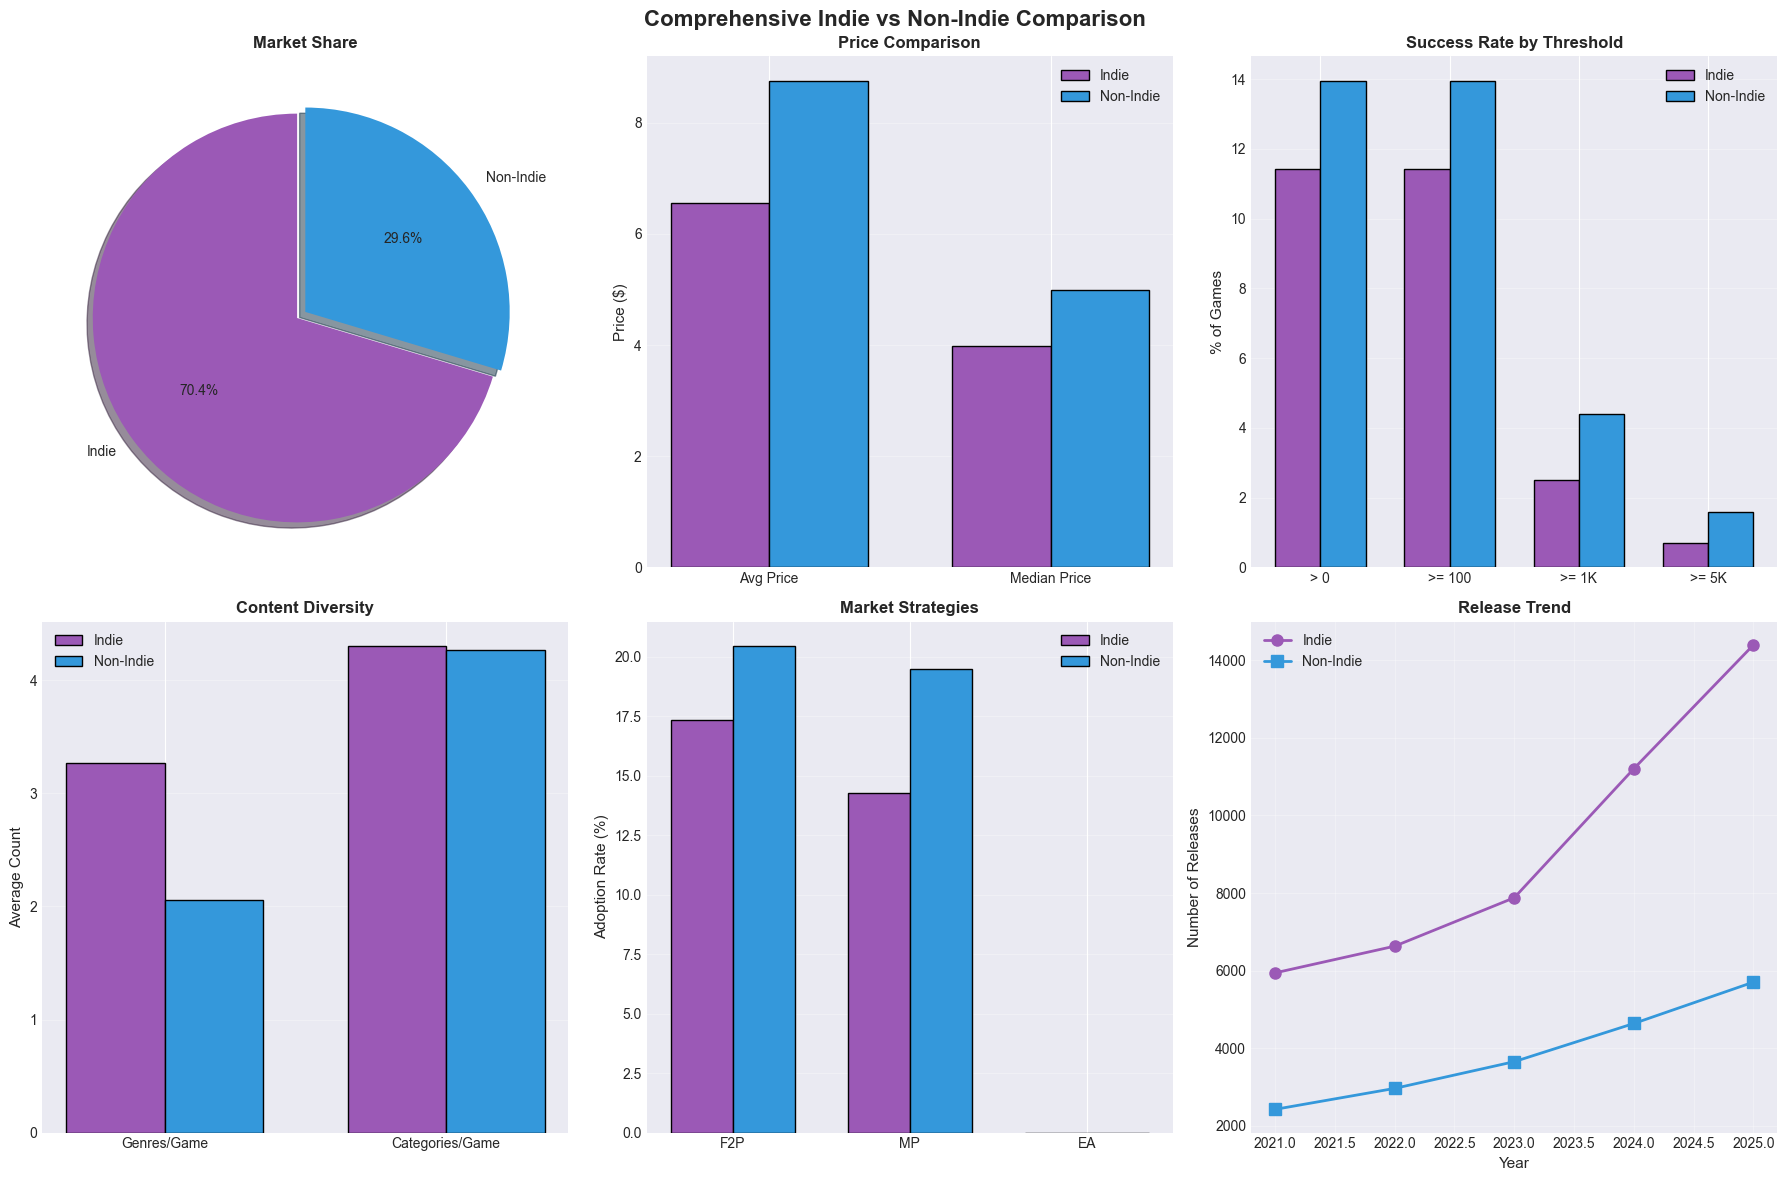


✓ COMPREHENSIVE INDIE VS NON-INDIE ANALYSIS COMPLETED!

📝 KEY FINDINGS:
   • Indie games represent 70.4% of the Steam market
   • Indie games are $2.20 cheaper on average
   • Non-Indie games have 1.9% higher success rate
   • Indie developers self-publish 76.2% of the time
   • 17.3% of Indie games are free-to-play


In [ ]:
# 6. COMPREHENSIVE SUMMARY: INDIE VS NON-INDIE
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY: INDIE VS NON-INDIE GAMES")
print("="*80)

if 'genres_list' in df_clean.columns:
    df_indie = df_clean[df_clean['genres_list'].apply(lambda x: 'Indie' in x if isinstance(x, list) else False)]
    df_non_indie = df_clean[~df_clean['genres_list'].apply(lambda x: 'Indie' in x if isinstance(x, list) else False)]
    
    print(f"\n📊 OVERALL STATISTICS:")
    print(f"   {'Metric':<30} {'Indie':>15} {'Non-Indie':>15} {'Diff':>12}")
    print(f"   {'-'*75}")
    
    # Dataset size
    indie_pct = len(df_indie) / len(df_clean) * 100
    non_indie_pct = len(df_non_indie) / len(df_clean) * 100
    print(f"   {'Total Games':<30} {len(df_indie):>15,} {len(df_non_indie):>15,}")
    print(f"   {'Market Share':<30} {indie_pct:>14.1f}% {non_indie_pct:>14.1f}%")
    
    # Price
    print(f"\n💰 PRICING:")
    print(f"   {'Average Price':<30} ${df_indie['price'].mean():>14.2f} ${df_non_indie['price'].mean():>14.2f} ${df_indie['price'].mean() - df_non_indie['price'].mean():>11.2f}")
    print(f"   {'Median Price':<30} ${df_indie['price'].median():>14.2f} ${df_non_indie['price'].median():>14.2f} ${df_indie['price'].median() - df_non_indie['price'].median():>11.2f}")
    indie_free = (df_indie['price'] == 0).sum() / len(df_indie) * 100
    non_indie_free = (df_non_indie['price'] == 0).sum() / len(df_non_indie) * 100
    print(f"   {'Free Games %':<30} {indie_free:>14.1f}% {non_indie_free:>14.1f}% {indie_free - non_indie_free:>11.1f}%")
    
    # Success
    print(f"\n⭐ SUCCESS METRICS:")
    print(f"   {'Avg Recommendations':<30} {df_indie['recommendations'].mean():>15,.0f} {df_non_indie['recommendations'].mean():>15,.0f}")
    print(f"   {'Median Recommendations':<30} {df_indie['recommendations'].median():>15,.0f} {df_non_indie['recommendations'].median():>15,.0f}")
    indie_success = (df_indie['recommendations'] >= 1000).sum() / len(df_indie) * 100
    non_indie_success = (df_non_indie['recommendations'] >= 1000).sum() / len(df_non_indie) * 100
    print(f"   {'Success Rate (>=1000)':<30} {indie_success:>14.1f}% {non_indie_success:>14.1f}% {indie_success - non_indie_success:>11.1f}%")
    
    # Diversity
    print(f"\n🎯 CONTENT DIVERSITY:")
    if 'genre_count' in df_clean.columns:
        print(f"   {'Avg Genres per Game':<30} {df_indie['genre_count'].mean():>15.2f} {df_non_indie['genre_count'].mean():>15.2f}")
    if 'category_count' in df_clean.columns:
        print(f"   {'Avg Categories per Game':<30} {df_indie['category_count'].mean():>15.2f} {df_non_indie['category_count'].mean():>15.2f}")
    
    # Market Strategies
    print(f"\n🎮 MARKET STRATEGIES:")
    if 'is_free' in df_clean.columns:
        indie_free_strat = (df_indie['is_free'] == 1).sum() / len(df_indie) * 100
        non_indie_free_strat = (df_non_indie['is_free'] == 1).sum() / len(df_non_indie) * 100
        print(f"   {'Free-to-Play Adoption':<30} {indie_free_strat:>14.1f}% {non_indie_free_strat:>14.1f}%")
    
    if 'is_multiplayer' in df_clean.columns:
        indie_mp = (df_indie['is_multiplayer'] == 1).sum() / len(df_indie) * 100
        non_indie_mp = (df_non_indie['is_multiplayer'] == 1).sum() / len(df_non_indie) * 100
        print(f"   {'Multiplayer Support':<30} {indie_mp:>14.1f}% {non_indie_mp:>14.1f}%")
    
    if 'is_early_access' in df_clean.columns:
        indie_ea = (df_indie['is_early_access'] == 1).sum() / len(df_indie) * 100
        non_indie_ea = (df_non_indie['is_early_access'] == 1).sum() / len(df_non_indie) * 100
        print(f"   {'Early Access Usage':<30} {indie_ea:>14.1f}% {non_indie_ea:>14.1f}%")
    
    # Developer behavior
    if 'developer' in df_clean.columns and 'publisher' in df_clean.columns:
        indie_self_pub = (df_indie['developer'] == df_indie['publisher']).sum() / len(df_indie) * 100
        non_indie_self_pub = (df_non_indie['developer'] == df_non_indie['publisher']).sum() / len(df_non_indie) * 100
        print(f"\n👨‍💻 PUBLISHING:")
        print(f"   {'Self-Publishing Rate':<30} {indie_self_pub:>14.1f}% {non_indie_self_pub:>14.1f}%")
    
    # Create comprehensive comparison visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Comprehensive Indie vs Non-Indie Comparison', fontsize=16, fontweight='bold')
    
    # 1. Market share
    ax1 = axes[0, 0]
    sizes = [len(df_indie), len(df_non_indie)]
    colors = ['#9b59b6', '#3498db']
    explode = (0.05, 0)
    ax1.pie(sizes, labels=['Indie', 'Non-Indie'], autopct='%1.1f%%',
            startangle=90, colors=colors, explode=explode, shadow=True)
    ax1.set_title('Market Share', fontsize=12, fontweight='bold')
    
    # 2. Price comparison
    ax2 = axes[0, 1]
    categories = ['Avg Price', 'Median Price']
    indie_vals = [df_indie['price'].mean(), df_indie['price'].median()]
    non_indie_vals = [df_non_indie['price'].mean(), df_non_indie['price'].median()]
    
    x = np.arange(len(categories))
    width = 0.35
    
    ax2.bar(x - width/2, indie_vals, width, label='Indie', color='#9b59b6', edgecolor='black')
    ax2.bar(x + width/2, non_indie_vals, width, label='Non-Indie', color='#3498db', edgecolor='black')
    ax2.set_ylabel('Price ($)', fontsize=11)
    ax2.set_title('Price Comparison', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(categories)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Success rate
    ax3 = axes[0, 2]
    thresholds = ['> 0', '>= 100', '>= 1K', '>= 5K']
    threshold_vals = [0, 100, 1000, 5000]
    
    indie_success_rates = [(df_indie['recommendations'] > t).sum() / len(df_indie) * 100 for t in threshold_vals]
    non_indie_success_rates = [(df_non_indie['recommendations'] > t).sum() / len(df_non_indie) * 100 for t in threshold_vals]
    
    x = np.arange(len(thresholds))
    width = 0.35
    
    ax3.bar(x - width/2, indie_success_rates, width, label='Indie', color='#9b59b6', edgecolor='black')
    ax3.bar(x + width/2, non_indie_success_rates, width, label='Non-Indie', color='#3498db', edgecolor='black')
    ax3.set_ylabel('% of Games', fontsize=11)
    ax3.set_title('Success Rate by Threshold', fontsize=12, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(thresholds)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Content diversity
    ax4 = axes[1, 0]
    if 'genre_count' in df_clean.columns and 'category_count' in df_clean.columns:
        categories = ['Genres/Game', 'Categories/Game']
        indie_vals = [df_indie['genre_count'].mean(), df_indie['category_count'].mean()]
        non_indie_vals = [df_non_indie['genre_count'].mean(), df_non_indie['category_count'].mean()]
        
        x = np.arange(len(categories))
        width = 0.35
        
        ax4.bar(x - width/2, indie_vals, width, label='Indie', color='#9b59b6', edgecolor='black')
        ax4.bar(x + width/2, non_indie_vals, width, label='Non-Indie', color='#3498db', edgecolor='black')
        ax4.set_ylabel('Average Count', fontsize=11)
        ax4.set_title('Content Diversity', fontsize=12, fontweight='bold')
        ax4.set_xticks(x)
        ax4.set_xticklabels(categories)
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)
    
    # 5. Market strategies
    ax5 = axes[1, 1]
    strategies = ['F2P', 'MP', 'EA']
    indie_strat_vals = []
    non_indie_strat_vals = []
    
    if 'is_free' in df_clean.columns:
        indie_strat_vals.append((df_indie['is_free'] == 1).sum() / len(df_indie) * 100)
        non_indie_strat_vals.append((df_non_indie['is_free'] == 1).sum() / len(df_non_indie) * 100)
    
    if 'is_multiplayer' in df_clean.columns:
        indie_strat_vals.append((df_indie['is_multiplayer'] == 1).sum() / len(df_indie) * 100)
        non_indie_strat_vals.append((df_non_indie['is_multiplayer'] == 1).sum() / len(df_non_indie) * 100)
    
    if 'is_early_access' in df_clean.columns:
        indie_strat_vals.append((df_indie['is_early_access'] == 1).sum() / len(df_indie) * 100)
        non_indie_strat_vals.append((df_non_indie['is_early_access'] == 1).sum() / len(df_non_indie) * 100)
    
    x = np.arange(len(strategies))
    width = 0.35
    
    ax5.bar(x - width/2, indie_strat_vals, width, label='Indie', color='#9b59b6', edgecolor='black')
    ax5.bar(x + width/2, non_indie_strat_vals, width, label='Non-Indie', color='#3498db', edgecolor='black')
    ax5.set_ylabel('Adoption Rate (%)', fontsize=11)
    ax5.set_title('Market Strategies', fontsize=12, fontweight='bold')
    ax5.set_xticks(x)
    ax5.set_xticklabels(strategies)
    ax5.legend()
    ax5.grid(axis='y', alpha=0.3)
    
    # 6. Release trend
    ax6 = axes[1, 2]
    if 'release_year' in df_clean.columns:
        years = sorted(df_clean['release_year'].unique())
        indie_by_year = df_indie.groupby('release_year').size()
        non_indie_by_year = df_non_indie.groupby('release_year').size()
        
        indie_counts = [indie_by_year.get(year, 0) for year in years]
        non_indie_counts = [non_indie_by_year.get(year, 0) for year in years]
        
        ax6.plot(years, indie_counts, marker='o', linewidth=2, markersize=8,
                color='#9b59b6', label='Indie')
        ax6.plot(years, non_indie_counts, marker='s', linewidth=2, markersize=8,
                color='#3498db', label='Non-Indie')
        ax6.set_xlabel('Year', fontsize=11)
        ax6.set_ylabel('Number of Releases', fontsize=11)
        ax6.set_title('Release Trend', fontsize=12, fontweight='bold')
        ax6.legend()
        ax6.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("✓ COMPREHENSIVE INDIE VS NON-INDIE ANALYSIS COMPLETED!")
    print("="*80)
    print(f"\n📝 KEY FINDINGS:")
    print(f"   • Indie games represent {indie_pct:.1f}% of the Steam market")
    print(f"   • Indie games are ${df_non_indie['price'].mean() - df_indie['price'].mean():.2f} cheaper on average")
    print(f"   • Non-Indie games have {non_indie_success - indie_success:.1f}% higher success rate")
    print(f"   • Indie developers self-publish {indie_self_pub:.1f}% of the time")
    print(f"   • {indie_free:.1f}% of Indie games are free-to-play")


## 10. Export Processed Data

## 11. SQL Integration
To demonstrate SQL skills, the cleaned dataframe is persisted to a local SQLite database so we can run joins, filters, and aggregations that reinforce the indie-focused research questions.

In [ ]:
print("="*80)
print("PERSISTING DATAFRAME TO SQLITE")
print("="*80)

# Ensure list-like columns are serialized before writing to SQLite
safe_df = df_clean.copy()
list_like_columns = [
    col for col in safe_df.columns
    if safe_df[col].apply(lambda val: isinstance(val, list)).any()
]
for col in list_like_columns:
    safe_df[col] = safe_df[col].apply(
        lambda val: ';'.join(str(item) for item in val) if isinstance(val, list) else val
    )

# Some columns may mix dicts/sets; convert anything non-serializable to string
object_columns = [col for col in safe_df.columns if safe_df[col].dtype == 'object']
for col in object_columns:
    safe_df[col] = safe_df[col].apply(
        lambda val: val if isinstance(val, (str, int, float, type(None))) else str(val)
    )

db_path = Path('data/steam_games.sqlite')
conn = sqlite3.connect(db_path)

# Persist the sanitized dataset
safe_df.to_sql('steam_games', conn, if_exists='replace', index=False)

# Build a compact developer summary table for join examples
developer_summary = (
    safe_df.groupby(['developer', 'is_indie'])
          .agg(total_games=('appid', 'count'),
               avg_price=('price', 'mean'),
               avg_recommendations=('recommendations', 'mean'))
          .reset_index()
)
developer_summary['segment'] = developer_summary['is_indie'].map({1: 'Indie', 0: 'Non-Indie'})
developer_summary.to_sql('developer_summary', conn, if_exists='replace', index=False)

print(f"Database created at: {db_path}")
print(f"steam_games rows: {len(safe_df):,}")
print(f"developer_summary rows: {len(developer_summary):,}")

PERSISTING DATAFRAME TO SQLITE
Database created at: data\steam_games.sqlite
steam_games rows: 65,454
developer_summary rows: 47,990


In [ ]:
print("\n" + "-"*80)
print("SQL QUERY 1: Yearly price & recommendation averages by segment")
print("-"*80)

yearly_sql = """\
WITH indie_flag AS (
    SELECT 
        release_year,
        CASE WHEN is_indie = 1 THEN 'Indie' ELSE 'Non-Indie' END AS segment,
        price,
        recommendations
    FROM steam_games
    WHERE release_year IS NOT NULL
)
SELECT 
    release_year,
    segment,
    COUNT(*) AS game_count,
    AVG(price) AS avg_price,
    AVG(recommendations) AS avg_recommendations
FROM indie_flag
GROUP BY release_year, segment
ORDER BY release_year, segment;
"""
yearly_segment_stats = pd.read_sql_query(yearly_sql, conn)
display(yearly_segment_stats.head(12))


--------------------------------------------------------------------------------
SQL QUERY 1: Yearly price & recommendation averages by segment
--------------------------------------------------------------------------------


,release_year,segment,game_count,avg_price,avg_recommendations
0,2021,Indie,5944,6.051691,265.879206
1,2021,Non-Indie,2427,8.027141,791.871034
2,2022,Indie,6632,6.416451,275.597407
3,2022,Non-Indie,2967,8.758969,943.982474
4,2023,Indie,7880,7.030588,302.618655
5,2023,Non-Indie,3656,9.089335,533.301696
6,2024,Indie,11206,7.030435,268.036409
7,2024,Non-Indie,4640,8.918703,656.297845
8,2025,Indie,14396,6.188417,156.769519
9,2025,Non-Indie,5706,8.722841,514.784613


In [ ]:
print("\n" + "-"*80)
print("SQL QUERY 2: Join steam_games with developer_summary for portfolio insights")
print("-"*80)

portfolio_sql = """\
WITH joined AS (
    SELECT 
        s.developer,
        CASE WHEN s.is_indie = 1 THEN 'Indie' ELSE 'Non-Indie' END AS segment,
        ds.total_games,
        s.recommendations,
        s.price
    FROM steam_games AS s
    INNER JOIN developer_summary AS ds
        ON s.developer = ds.developer AND s.is_indie = ds.is_indie
)
SELECT 
    segment,
    CASE WHEN total_games = 1 THEN 'Single-Release Teams' ELSE 'Portfolio Teams' END AS portfolio_type,
    COUNT(DISTINCT developer) AS developer_count,
    AVG(price) AS avg_price,
    AVG(recommendations) AS avg_recommendations
FROM joined
GROUP BY segment, portfolio_type
ORDER BY segment, portfolio_type;
"""
portfolio_stats = pd.read_sql_query(portfolio_sql, conn)
display(portfolio_stats)


--------------------------------------------------------------------------------
SQL QUERY 2: Join steam_games with developer_summary for portfolio insights
--------------------------------------------------------------------------------


,segment,portfolio_type,developer_count,avg_price,avg_recommendations
0,Indie,Portfolio Teams,5139,7.555583,192.974612
1,Indie,Single-Release Teams,28924,5.958385,267.833840
2,Non-Indie,Portfolio Teams,2047,10.847499,768.169106
3,Non-Indie,Single-Release Teams,11880,7.434836,579.245960


In [ ]:
print("\n" + "-"*80)
print("SQL QUERY 3: High-volume genres with success filters")
print("-"*80)

genre_sql = """\
WITH genre_scores AS (
    SELECT 
        CASE WHEN is_indie = 1 THEN 'Indie' ELSE 'Non-Indie' END AS segment,
        primary_genre,
        COUNT(*) AS releases,
        AVG(recommendations) AS avg_recommendations,
        SUM(CASE WHEN recommendations >= 1000 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS success_rate
    FROM steam_games
    WHERE primary_genre NOT IN ('Unspecified', '')
    GROUP BY segment, primary_genre
    HAVING COUNT(*) >= 40
)
SELECT *
FROM genre_scores
ORDER BY segment, success_rate DESC;
"""
genre_stats = pd.read_sql_query(genre_sql, conn)
display(genre_stats.head(20))


--------------------------------------------------------------------------------
SQL QUERY 3: High-volume genres with success filters
--------------------------------------------------------------------------------


,segment,primary_genre,releases,avg_recommendations,success_rate
0,Indie,Adventure,10179,232.106887,0.031437
1,Indie,Action,18835,323.765968,0.026068
2,Indie,Indie,6064,180.843832,0.024077
3,Indie,Casual,10883,137.449968,0.018194
4,Indie,Free To Play,97,0.000000,0.000000
5,Non-Indie,Racing,277,495.039711,0.072202
6,Non-Indie,Simulation,1388,684.087896,0.066282
7,Non-Indie,Action,6884,1378.641197,0.063045
8,Non-Indie,RPG,1172,462.854096,0.058020
9,Non-Indie,Massively Multiplayer,123,394.203252,0.048780


In [ ]:
conn.close()
print("\nSQLite connection closed.")


SQLite connection closed.


In [ ]:
# Save the cleaned and processed dataset
output_filename = 'data/steam_data_processed.csv'

df_clean.to_csv(output_filename, sep=';', index=False, encoding='utf-8')

print("="*80)
print("DATA EXPORT COMPLETED")
print("="*80)
print(f"✓ Processed data saved to: {output_filename}")
print(f"✓ Total records: {len(df_clean):,}")
print(f"✓ Total features: {df_clean.shape[1]}")
print("\n📋 Available columns:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"   {i:2d}. {col}")

DATA EXPORT COMPLETED
✓ Processed data saved to: data/steam_data_processed.csv
✓ Total records: 65,454
✓ Total features: 24

📋 Available columns:
    1. appid
    2. name
    3. release_year
    4. release_date
    5. genres
    6. categories
    7. price
    8. recommendations
    9. developer
   10. publisher
   11. genres_split
   12. has_valid_developer
   13. has_valid_publisher
   14. genres_list
   15. genre_count
   16. categories_list
   17. category_count
   18. price_category
   19. popularity
   20. is_free
   21. is_early_access
   22. is_multiplayer
   23. is_indie
   24. primary_genre


In [ ]:
# Display sample of the final processed data
print("\n" + "="*80)
print("SAMPLE OF PROCESSED DATA")
print("="*80)
display(df_clean.head(10))


SAMPLE OF PROCESSED DATA


,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher,genres_split,has_valid_developer,has_valid_publisher,genres_list,genre_count,categories_list,category_count,price_category,popularity,is_free,is_early_access,is_multiplayer,is_indie,primary_genre
0,3057270,Seafarer's Gambit,2024,"Jul 5, 2024",Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios,"[Action, Adventure, Indie, RPG, Strategy]",1,1,"[Action, Adventure, Indie, RPG, Strategy]",5,"[Single-player, Family Sharing]",2,Budget,None,0,0,0,1,Action
1,3822840,Capitalist Misadventures,2025,"Jul 25, 2025",Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios,"[Casual, Indie, Simulation, Strategy]",1,1,"[Casual, Indie, Simulation, Strategy]",4,"[Single-player, Save Anytime, Family Sharing]",3,Standard,None,0,0,0,1,Casual
2,3216640,The Beast and the Princess,2025,"Jun 17, 2025",Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames,"[Adventure, Indie, Strategy]",1,1,"[Adventure, Indie, Strategy]",3,"[Single-player, Steam Achievements, Full contr...",9,Standard,None,0,0,0,1,Adventure
3,2403620,Air Twister,2023,"Nov 10, 2023",Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ,"[Action, Adventure, Indie]",1,1,"[Action, Adventure, Indie]",3,"[Single-player, Steam Achievements, Full contr...",5,Premium,None,0,0,0,1,Action
4,1538040,Horde Slayer,2021,"Mar 19, 2021",Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues,"[Action, Adventure, Casual, Indie, RPG, Early ...",1,1,"[Action, Adventure, Casual, Indie, RPG, Early ...",6,"[Single-player, Steam Achievements, Full contr...",5,Budget,None,0,0,0,1,Action
5,1724980,The Lone Blade,2023,"May 23, 2023",Action;Adventure;Indie,Single-player;Full controller support;Family S...,1.99,0,Opia Games,Opia Games;Plug In Digital,"[Action, Adventure, Indie]",1,1,"[Action, Adventure, Indie]",3,"[Single-player, Full controller support, Famil...",3,Budget,None,0,0,0,1,Action
6,3822820,Knight Crawler,2025,"Jul 16, 2025",Action;Indie;Free To Play,Single-player;Full controller support;Custom V...,0.00,0,Taylor Conolley,Taylor Conolley,"[Action, Indie, Free To Play]",1,1,"[Action, Indie, Free To Play]",3,"[Single-player, Full controller support, Custo...",5,Free,None,1,0,0,1,Action
7,3863460,No Sweet Looks,2025,"Aug 28, 2025",Action;Indie,Single-player;Steam Achievements;Full controll...,2.99,0,halvardo13,halvardo13,"[Action, Indie]",1,1,"[Action, Indie]",2,"[Single-player, Steam Achievements, Full contr...",7,Budget,None,0,0,0,1,Action
8,3216610,League Of Tacticians: Path of Tarkan,2025,"May 21, 2025",Adventure;RPG;Strategy,Single-player;Family Sharing,3.99,0,Oba Games,Oba Games,"[Adventure, RPG, Strategy]",1,1,"[Adventure, RPG, Strategy]",3,"[Single-player, Family Sharing]",2,Budget,None,0,0,0,0,Adventure
9,3057250,Pennylooter,2025,"Sep 8, 2025",Action;Indie,Single-player;Steam Achievements;Full controll...,6.99,0,Josh Sellers,Josh Sellers,"[Action, Indie]",1,1,"[Action, Indie]",2,"[Single-player, Steam Achievements, Full contr...",5,Standard,None,0,0,0,1,Action


In [ ]:
# Verify that genres and categories are now vectors (lists)
print("="*80)
print("VERIFYING GENRES AND CATEGORIES AS VECTORS")
print("="*80)

# Check a sample row
sample_row = df_clean.iloc[0]

print("\n📌 Example from first game:")
print(f"Game: {sample_row['name']}")
print(f"\nOriginal genres string: {sample_row['genres']}")
print(f"Genres as list: {sample_row['genres_list']}")
print(f"Type: {type(sample_row['genres_list'])}")
print(f"Number of genres: {len(sample_row['genres_list'])}")

print(f"\nOriginal categories string: {sample_row['categories']}")
print(f"Categories as list: {sample_row['categories_list']}")
print(f"Type: {type(sample_row['categories_list'])}")
print(f"Number of categories: {len(sample_row['categories_list'])}")

print("\n" + "="*80)
print("✓ Yes! Genres and categories are now vectors (lists) of individual elements")
print("="*80)

VERIFYING GENRES AND CATEGORIES AS VECTORS

📌 Example from first game:
Game: Seafarer's Gambit

Original genres string: Action;Adventure;Indie;RPG;Strategy
Genres as list: ['Action', 'Adventure', 'Indie', 'RPG', 'Strategy']
Type: <class 'list'>
Number of genres: 5

Original categories string: Single-player;Family Sharing
Categories as list: ['Single-player', 'Family Sharing']
Type: <class 'list'>
Number of categories: 2

✓ Yes! Genres and categories are now vectors (lists) of individual elements


In [ ]:
# Count unique values in categorical columns
print("="*80)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*80)

# Basic categorical columns
print("\n📋 BASIC CATEGORICAL COLUMNS:")
print("-" * 60)
if 'name' in df_clean.columns:
    print(f"   Game Names:        {df_clean['name'].nunique():>6,} unique games")
if 'developer' in df_clean.columns:
    print(f"   Developers:        {df_clean['developer'].nunique():>6,} unique developers")
if 'publisher' in df_clean.columns:
    print(f"   Publishers:        {df_clean['publisher'].nunique():>6,} unique publishers")

# Genre and category unique counts
print("\n🎮 GENRES & CATEGORIES:")
print("-" * 60)
if 'genres_list' in df_clean.columns:
    # Count unique genres across all games
    all_genres = []
    for genres in df_clean['genres_list']:
        if isinstance(genres, list):
            all_genres.extend(genres)
    unique_genres = len(set(all_genres))
    print(f"   Unique Genres:     {unique_genres:>6,} different genres")
    
if 'categories_list' in df_clean.columns:
    # Count unique categories across all games
    all_categories = []
    for cats in df_clean['categories_list']:
        if isinstance(cats, list):
            all_categories.extend(cats)
    unique_categories = len(set(all_categories))
    print(f"   Unique Categories: {unique_categories:>6,} different categories")

if 'primary_genre' in df_clean.columns:
    print(f"   Primary Genres:    {df_clean['primary_genre'].nunique():>6,} unique primary genres")

# Derived categorical columns
print("\n🏷️  DERIVED CATEGORIES:")
print("-" * 60)
if 'price_category' in df_clean.columns:
    print(f"   Price Categories:  {df_clean['price_category'].nunique():>6,} categories")
    print(f"      {', '.join(df_clean['price_category'].unique().astype(str))}")
    
if 'popularity' in df_clean.columns:
    print(f"   Popularity Levels: {df_clean['popularity'].nunique():>6,} levels")
    print(f"      {', '.join(df_clean['popularity'].unique().astype(str))}")

# Release year
if 'release_year' in df_clean.columns:
    print(f"   Release Years:     {df_clean['release_year'].nunique():>6,} different years")
    print(f"      Range: {int(df_clean['release_year'].min())} - {int(df_clean['release_year'].max())}")

print("\n" + "="*80)
print(f"✓ Analysis complete for {len(df_clean):,} games")
print("="*80)

UNIQUE VALUES IN CATEGORICAL COLUMNS

📋 BASIC CATEGORICAL COLUMNS:
------------------------------------------------------------
   Game Names:        65,061 unique games


   Developers:        45,591 unique developers
   Publishers:        41,288 unique publishers

🎮 GENRES & CATEGORIES:
------------------------------------------------------------
   Unique Genres:         22 different genres
   Unique Categories:     55 different categories
   Primary Genres:        13 unique primary genres

🏷️  DERIVED CATEGORIES:
------------------------------------------------------------
   Price Categories:       5 categories
      Budget, Standard, Premium, Free, Expensive
   Popularity Levels:      4 levels
      None, Medium, High, Very High
   Release Years:          5 different years
      Range: 2021 - 2025

✓ Analysis complete for 65,454 games


In [ ]:
# Proper genre analysis using explode() - counts ALL genres per game
print("="*80)
print("COMPREHENSIVE GENRE ANALYSIS (ALL GENRES COUNTED)")
print("="*80)

if 'genres_list' in df_clean.columns:
    # Explode genres_list to count each genre properly
    genre_expanded = df_clean.explode('genres_list')
    
    # Count all genres
    all_genre_counts = genre_expanded['genres_list'].value_counts()
    
    print(f"\n📊 TOTAL GENRE OCCURRENCES:")
    print(f"   Total genre tags: {len(all_genre_counts):,}")
    print(f"   Total genre assignments: {all_genre_counts.sum():,}")
    print(f"   (Games can have multiple genres)")
    
    print(f"\n🎮 TOP 15 GENRES (All occurrences counted):")
    print("-" * 60)
    for i, (genre, count) in enumerate(all_genre_counts.head(15).items(), 1):
        percentage = (count / len(df_clean)) * 100
        print(f"   {i:2d}. {genre:<20} {count:>6,} games ({percentage:>5.1f}%)")
    
    # Comparison with primary_genre approach
    if 'primary_genre' in df_clean.columns:
        primary_counts = df_clean['primary_genre'].value_counts()
        
        print(f"\n⚖️  COMPARISON: Full Analysis vs Primary Genre Only:")
        print("-" * 60)
        print(f"   Method                    | Top Genre | Count")
        print(f"   {'-'*60}")
        top_full = all_genre_counts.iloc[0]
        top_primary = primary_counts.iloc[0]
        print(f"   Full (exploded)           | {all_genre_counts.index[0]:<9} | {top_full:>6,}")
        print(f"   Primary only              | {primary_counts.index[0]:<9} | {top_primary:>6,}")
        print(f"   Difference                |           | {top_full - top_primary:>6,} (+{((top_full - top_primary)/top_primary*100):.1f}%)")
        
        print(f"\n💡 Insight: Full analysis counts games with multiple genres for each genre,")
        print(f"   giving a more accurate picture of genre popularity!")

print("\n" + "="*80)

COMPREHENSIVE GENRE ANALYSIS (ALL GENRES COUNTED)

📊 TOTAL GENRE OCCURRENCES:
   Total genre tags: 22
   Total genre assignments: 190,556
   (Games can have multiple genres)

🎮 TOP 15 GENRES (All occurrences counted):
------------------------------------------------------------
    1. Indie                46,058 games ( 70.4%)
    2. Casual               30,710 games ( 46.9%)
    3. Adventure            26,545 games ( 40.6%)
    4. Action               25,719 games ( 39.3%)
    5. Simulation           14,514 games ( 22.2%)
    6. Strategy             12,994 games ( 19.9%)
    7. RPG                  12,644 games ( 19.3%)
    8. Free To Play          8,043 games ( 12.3%)
    9. Early Access          6,920 games ( 10.6%)
   10. Sports                2,576 games (  3.9%)
   11. Racing                2,350 games (  3.6%)
   12. Massively Multiplayer  1,382 games (  2.1%)
   13. Game Development         22 games (  0.0%)
   14. Utilities                19 games (  0.0%)
   15. Education    

## 📝 Processing Summary

### What Was Done:

1. **Data Loading** ✓
   - Loaded Steam games dataset (2021-2025)
   - Handled semicolon-delimited CSV format

2. **Data Cleaning** ✓
   - Removed duplicate entries
   - Handled missing values strategically
   - Converted data types appropriately
   - Cleaned text fields (whitespace, invalid entries)
   - **Split genres by semicolon** for better analysis
   - **Validated critical fields** (genre, developer, publisher)
   - **Separated games without valid genre** to separate dataset (`steam_data_invalid_genre.csv`)
   - Added validation flags for developer and publisher

3. **Feature Engineering** ✓
   - Parsed genres and categories into lists
   - Created genre/category count features
   - Added price categories (Free, Budget, Standard, Premium, Expensive)
   - Created popularity levels based on recommendations
   - Added binary flags (is_free, is_early_access, is_multiplayer)
   - Extracted primary genre for each game

4. **Data Validation** ✓
   - Verified no missing critical values
   - Checked data type consistency
   - Validated value ranges
   - Identified outliers

5. **Data Visualization** ✓
   - Price distribution analysis
   - Genre popularity breakdown
   - Release year trends
   - Price vs recommendations correlation

6. **Export** ✓
   - Saved processed dataset for future analysis
   - Dataset ready for machine learning, analytics, or reporting

### Next Steps:
- Use `df_clean` for any further analysis
- The processed data is saved in `data/steam_data_processed.csv`
- Ready for predictive modeling, dashboard creation, or statistical analysis

## Steam Awards Integration

Now we'll load and merge the Steam Awards nominees dataset with our main data.

In [ ]:
# Load Steam Awards data
awards_path = "data/steam_awards_nominees.csv"
df_awards = pd.read_csv(awards_path)

print(f"Steam Awards dataset: {df_awards.shape[0]} rows, {df_awards.shape[1]} columns")
print(f"\nYears covered: {sorted(df_awards['year'].unique())}")
print(f"Categories: {df_awards['category'].nunique()}")
print(f"Winners: {df_awards['is_winner'].sum()}")
print(f"Nominees (non-winners): {(df_awards['is_winner'] == 0).sum()}")

# Display first few entries
df_awards.head(10)

Steam Awards dataset: 270 rows, 5 columns

Years covered: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Categories: 12
Winners: 54
Nominees (non-winners): 216


,year,category,game,is_winner,genres
0,2025,Game of the Year Award,Hollow Knight: Silksong,1,Action;Adventure;Indie
1,2025,Game of the Year Award,ARC Raiders,0,Action
2,2025,Game of the Year Award,Clair Obscur: Expedition 33,0,Action;RPG
3,2025,Game of the Year Award,Dispatch,0,Action;Adventure;Casual;Indie;Strategy
4,2025,Game of the Year Award,Kingdom Come: Deliverance II,0,Action;Adventure;RPG
5,2025,VR Game of the Year Award,The Midnight Walk,1,Adventure;Indie
6,2025,VR Game of the Year Award,Pavlov,0,Action;Indie
7,2025,VR Game of the Year Award,Emissary Zero,0,Adventure;Indie;Massively Multiplayer
8,2025,VR Game of the Year Award,F1® 25,0,Racing;Simulation;Sports
9,2025,VR Game of the Year Award,Le Mans Ultimate,0,Racing;Simulation;Sports


In [ ]:
# Create awards indicators - find which games in our main dataset were nominated/won awards
# First, let's see which games from awards data match our main dataset

awards_games = set(df_awards['game'].str.strip())
main_games = set(df_clean['name'].str.strip())

# Find matches
matching_games = awards_games.intersection(main_games)
print(f"\nGames in both datasets: {len(matching_games)}")
print(f"Awards games not in main dataset: {len(awards_games - main_games)}")
print(f"Main dataset games: {len(main_games)}")

# Show some matching games
if matching_games:
    print(f"\nExample matching games:")
    for game in sorted(matching_games)[:10]:
        print(f"  - {game}")


Games in both datasets: 143
Awards games not in main dataset: 73
Main dataset games: 65061

Example matching games:
  - ARC Raiders
  - Age of Empires IV: Anniversary Edition
  - Among Us 3D: VR
  - BONELAB
  - Balatro
  - Battlefield™ 2042
  - Battlefield™ 6
  - Black Myth: Wukong
  - Blair Witch VR
  - Blue Prince


In [ ]:
# Create aggregated awards data for each game
# For games with multiple nominations, we'll track:
# - Total nominations
# - Total wins
# - Years nominated
# - Categories nominated

awards_summary = df_awards.groupby('game').agg({
    'year': lambda x: ';'.join(map(str, sorted(set(x)))),
    'category': lambda x: ';'.join(sorted(set(x))),
    'is_winner': ['sum', 'count']
}).reset_index()

# Flatten column names
awards_summary.columns = ['game', 'award_years', 'award_categories', 'total_wins', 'total_nominations']

print(f"Games with awards data: {len(awards_summary)}")
print(f"\nTop games by nominations:")
print(awards_summary.sort_values('total_nominations', ascending=False).head(10))

awards_summary.head()

Games with awards data: 216

Top games by nominations:
                                     game               award_years  \
52                                 Dota 2  2021;2022;2023;2024;2025   
10                        Baldur's Gate 3            2023;2024;2025   
82                          HELLDIVERS™ 2                 2024;2025   
139                          No Man's Sky       2021;2022;2024;2025   
32                         Cyberpunk 2077                 2021;2022   
57                             ELDEN RING                 2022;2024   
14                     Black Myth: Wukong                      2024   
9                                 Balatro                      2024   
167  S.T.A.L.K.E.R. 2: Heart of Chornobyl                      2024   
166                                  Rust            2021;2023;2025   

                                      award_categories  total_wins  \
52                                 Labor of Love Award           0   
10   Game of the Year A

,game,award_years,award_categories,total_wins,total_nominations
0,A Plague Tale: Requiem,2022,Outstanding Story-Rich Game Award,0,1
1,ARC Raiders,2025,Game of the Year Award;Most Innovative Gamepla...,1,2
2,Age of Empires IV: Anniversary Edition,2021,Best Game You Suck At Award,0,1
3,Among Us 3D: VR,2022,VR Game of the Year Award,0,1
4,Apex Legends™,2021;2023,Labor of Love Award,0,2


In [ ]:
# Merge awards data into main dataset
df_enriched = df_clean.merge(
    awards_summary,
    left_on='name',
    right_on='game',
    how='left'
)

# Drop duplicate 'game' column
if 'game' in df_enriched.columns:
    df_enriched = df_enriched.drop('game', axis=1)

# Fill NaN values for games without awards
df_enriched['total_wins'] = df_enriched['total_wins'].fillna(0).astype(int)
df_enriched['total_nominations'] = df_enriched['total_nominations'].fillna(0).astype(int)
df_enriched['award_years'] = df_enriched['award_years'].fillna('')
df_enriched['award_categories'] = df_enriched['award_categories'].fillna('')

# Create binary flags
df_enriched['has_awards'] = (df_enriched['total_nominations'] > 0).astype(int)
df_enriched['is_award_winner'] = (df_enriched['total_wins'] > 0).astype(int)

print(f"Enriched dataset shape: {df_enriched.shape}")
print(f"\nAwards statistics:")
print(f"  Games with any nomination: {df_enriched['has_awards'].sum()}")
print(f"  Games with at least one win: {df_enriched['is_award_winner'].sum()}")
print(f"  Total wins in dataset: {df_enriched['total_wins'].sum()}")
print(f"  Total nominations in dataset: {df_enriched['total_nominations'].sum()}")

# Show example of enriched data
print(f"\nExample award-winning games:")
df_enriched[df_enriched['is_award_winner'] == 1][['name', 'total_wins', 'total_nominations', 'award_years', 'award_categories']].head(10)

Enriched dataset shape: (65454, 30)

Awards statistics:
  Games with any nomination: 143
  Games with at least one win: 33
  Total wins in dataset: 37
  Total nominations in dataset: 169

Example award-winning games:


,name,total_wins,total_nominations,award_years,award_categories
2588,DEATHLOOP,1,1,2021,Most Innovative Gameplay Award
2980,Dispatch,1,2,2025,Game of the Year Award;Outstanding Story-Rich ...
4147,Clair Obscur: Expedition 33,1,2,2025,Best Soundtrack Award;Game of the Year Award
6481,Cooking Simulator VR,1,1,2021,VR Game of the Year Award
8915,Labyrinthine,1,1,2023,VR Game of the Year Award
8963,HITMAN World of Assassination,1,1,2022,VR Game of the Year Award
9877,Farming Simulator 22,1,1,2021,Sit Back and Relax Award
12824,ELDEN RING,3,3,2022;2024,Best Game You Suck At Award;Game of the Year A...
12942,Starfield,1,1,2023,Most Innovative Gameplay Award
15882,Black Myth: Wukong,3,3,2024,Best Game You Suck At Award;Game of the Year A...


In [ ]:
# Analyze awards by indie vs non-indie
print("Awards Analysis: Indie vs Non-Indie\n")
print("="*60)

# Overall awards distribution
awards_by_segment = df_enriched.groupby('is_indie').agg({
    'has_awards': 'sum',
    'is_award_winner': 'sum',
    'total_nominations': 'sum',
    'total_wins': 'sum'
}).reset_index()

awards_by_segment['is_indie'] = awards_by_segment['is_indie'].map({1: 'Indie', 0: 'Non-Indie'})
print("\nAwards Distribution by Segment:")
print(awards_by_segment)

# Calculate percentages
indie_total = len(df_enriched[df_enriched['is_indie'] == 1])
non_indie_total = len(df_enriched[df_enriched['is_indie'] == 0])

indie_nominated_pct = (df_enriched[(df_enriched['is_indie'] == 1) & (df_enriched['has_awards'] == 1)].shape[0] / indie_total * 100)
non_indie_nominated_pct = (df_enriched[(df_enriched['is_indie'] == 0) & (df_enriched['has_awards'] == 1)].shape[0] / non_indie_total * 100)

print(f"\n% of Indie games nominated: {indie_nominated_pct:.2f}%")
print(f"% of Non-Indie games nominated: {non_indie_nominated_pct:.2f}%")

Awards Analysis: Indie vs Non-Indie


Awards Distribution by Segment:
    is_indie  has_awards  is_award_winner  total_nominations  total_wins
0  Non-Indie          89               23                106          27
1      Indie          54               10                 63          10

% of Indie games nominated: 0.12%
% of Non-Indie games nominated: 0.46%


In [ ]:
# Export enriched dataset
output_path_enriched = "data/steam_data_with_awards.csv"

df_enriched.to_csv(output_path_enriched, sep=";", index=False, encoding="utf-8")
print(f"✓ Enriched dataset saved to {output_path_enriched}")
print(f"  Shape: {df_enriched.shape}")
print(f"  Columns: {list(df_enriched.columns)}")

# Also update the processed dataset for backward compatibility
df_enriched.to_csv("data/steam_data_processed.csv", sep=";", index=False, encoding="utf-8")
print(f"✓ Updated steam_data_processed.csv with awards data")

✓ Enriched dataset saved to data/steam_data_with_awards.csv
  Shape: (65454, 30)
  Columns: ['appid', 'name', 'release_year', 'release_date', 'genres', 'categories', 'price', 'recommendations', 'developer', 'publisher', 'genres_split', 'has_valid_developer', 'has_valid_publisher', 'genres_list', 'genre_count', 'categories_list', 'category_count', 'price_category', 'popularity', 'is_free', 'is_early_access', 'is_multiplayer', 'is_indie', 'primary_genre', 'award_years', 'award_categories', 'total_wins', 'total_nominations', 'has_awards', 'is_award_winner']
✓ Updated steam_data_processed.csv with awards data


In [ ]:
# Save awards data to SQLite as well
awards_conn = sqlite3.connect(db_path)

# Save awards summary
awards_summary.to_sql('awards_summary', awards_conn, if_exists='replace', index=False)
print(f"✓ Awards summary saved to SQLite table 'awards_summary'")

# Save full awards data
df_awards.to_sql('awards_full', awards_conn, if_exists='replace', index=False)
print(f"✓ Full awards data saved to SQLite table 'awards_full'")

awards_conn.close()
print(f"\n✓ All data exported successfully!")

✓ Awards summary saved to SQLite table 'awards_summary'
✓ Full awards data saved to SQLite table 'awards_full'

✓ All data exported successfully!


In [ ]:
# Let's look at Dota 2's nomination history to understand multiple nominations
dota2_nominations = df_awards[df_awards['game'] == 'Dota 2']
print("Dota 2's Steam Awards History:")
print(dota2_nominations[['year', 'category', 'is_winner']].to_string(index=False))

print("\n" + "="*60)
print("\nThis shows Dota 2 was nominated 5 times across 5 years,")
print("likely for the 'Labor of Love Award' which recognizes ongoing support.")

Dota 2's Steam Awards History:
 year            category  is_winner
 2025 Labor of Love Award          0
 2024 Labor of Love Award          0
 2023 Labor of Love Award          0
 2022 Labor of Love Award          0
 2021 Labor of Love Award          0


This shows Dota 2 was nominated 5 times across 5 years,
likely for the 'Labor of Love Award' which recognizes ongoing support.
